# 다품목 주문 기반 집하장/사전재고 전략 분석

## 분석 목적

기존 분석에서 다품목 주문은 배송 지연 및 평점 하락의 주요 원인 중 하나로 나타났다.

따라서 본 분석에서는 다품목 주문 복잡성을 줄이기 위한 집하장 운영 전략을 검토한다.

분석 목표는 다음과 같다.

1. 다품목 주문에 자주 포함되는 품목을 파악한다.
2. 해당 품목을 많이 필요로 하는 고객 지역을 확인한다.
3. 지역-품목별 예상 수요를 머신러닝으로 예측한다.
4. 집하장에 어떤 품목을 어느 정도 보유해야 하는지 추정한다.
5. 집하장 후보 지역과 예상 평점 상승 효과를 산출한다.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 100)

df = pd.read_csv("../../../data/olist_delivered_item_level_cleaned_errors.csv")
df.shape

(108581, 68)

In [2]:
# 날짜 및 파생변수 생성
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["purchase_month_date"] = df["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()
df["category"] = df["product_category_name_english"].fillna("unknown")

df["delivery_gap_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

df["is_delay"] = df["delivery_gap_days"] > 0

order_item_count = df.groupby("order_id")["order_item_id"].count().rename("item_count")
df = df.merge(order_item_count, on="order_id", how="left")
df["is_multi_item_order"] = df["item_count"] >= 2

## 1. 다품목 주문에 많이 포함되는 품목 파악

다품목 주문은 단일 상품 주문보다 처리 복잡성이 높다.

특히 여러 상품을 한 주문에 묶어 처리해야 하므로, 재고 위치가 분산되어 있거나 일부 상품이 늦게 준비될 경우 전체 주문 경험이 나빠질 수 있다.

따라서 다품목 주문에 자주 포함되는 카테고리를 우선적으로 파악한다.

In [3]:
multi_df = df[df["is_multi_item_order"]].copy()

multi_category_summary = multi_df.groupby("category").agg(
    item_count=("order_item_id", "count"),
    order_count=("order_id", "nunique"),
    avg_review_score=("review_score_mean", "mean"),
    delay_rate=("is_delay", "mean"),
    avg_delivery_days=("delivery_days_clean", "mean")
).sort_values("order_count", ascending=False)

multi_category_summary["delay_rate_pct"] = multi_category_summary["delay_rate"] * 100

display(multi_category_summary.head(20))

,item_count,order_count,avg_review_score,delay_rate,avg_delivery_days,delay_rate_pct
category,,,,,,
bed_bath_table,3062,1409,3.509615,0.066297,11.413782,6.629654
furniture_decor,3176,1350,3.586323,0.081549,11.778338,8.154912
computers_accessories,1873,768,3.477187,0.079552,13.134010,7.955152
sports_leisure,1631,744,3.669245,0.047823,10.969344,4.782342
housewares,1742,733,3.671189,0.040758,9.600459,4.075775
health_beauty,1458,656,3.788959,0.089163,10.275034,8.916324
garden_tools,1407,591,3.674085,0.077470,13.432836,7.746979
watches_gifts,655,295,3.331279,0.050382,9.928244,5.038168
telephony,601,273,3.343384,0.061564,11.262895,6.156406


C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\3975458380.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


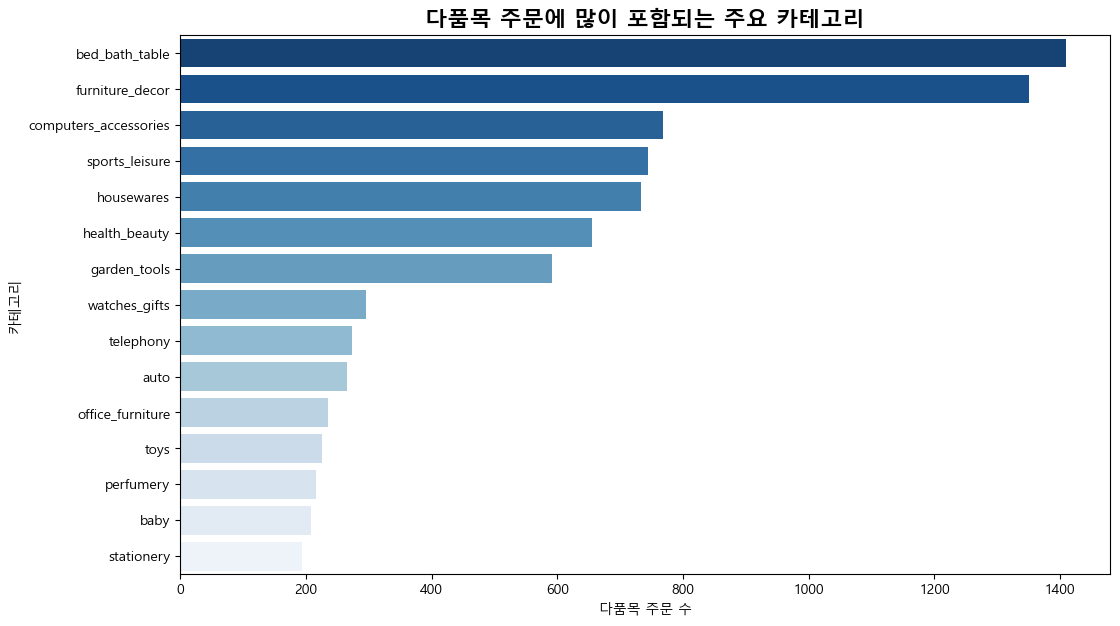

In [4]:
top_multi_categories = multi_category_summary.head(15).index

plt.figure(figsize=(12, 7))
sns.barplot(
    data=multi_category_summary.loc[top_multi_categories].reset_index(),
    y="category",
    x="order_count",
    palette="Blues_r"
)
plt.title("다품목 주문에 많이 포함되는 주요 카테고리", fontsize=16, weight="bold")
plt.xlabel("다품목 주문 수")
plt.ylabel("카테고리")
plt.show()

## 2. 주요 다품목 카테고리를 많이 필요로 하는 지역 파악

집하장에 어떤 품목을 적재할지는 지역 수요와 함께 판단해야 한다.

따라서 다품목 주문 주요 카테고리가 고객 권역별로 얼마나 필요한지 확인한다.

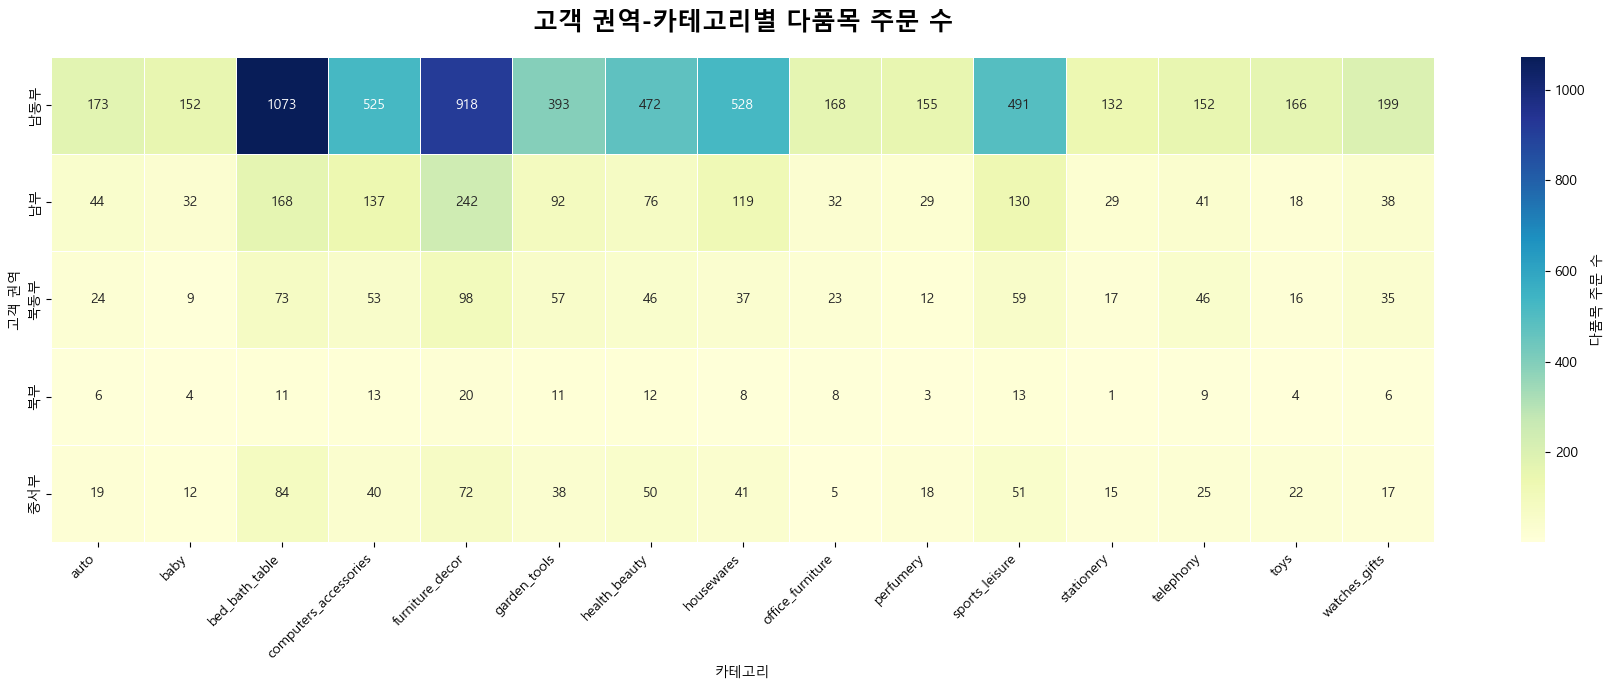

In [5]:
multi_top_df = multi_df[multi_df["category"].isin(top_multi_categories)].copy()

region_category_demand = multi_top_df.groupby(
    ["customer_region", "category"]
).agg(
    order_count=("order_id", "nunique"),
    item_count=("order_item_id", "count"),
    avg_review_score=("review_score_mean", "mean"),
    delay_rate=("is_delay", "mean"),
    avg_delivery_days=("delivery_days_clean", "mean")
).reset_index()

region_category_demand["delay_rate_pct"] = region_category_demand["delay_rate"] * 100

pivot_demand = region_category_demand.pivot_table(
    index="customer_region",
    columns="category",
    values="order_count",
    fill_value=0
)

plt.figure(figsize=(18, 7))
sns.heatmap(
    pivot_demand,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "다품목 주문 수"}
)
plt.title("고객 권역-카테고리별 다품목 주문 수", fontsize=18, weight="bold", pad=20)
plt.xlabel("카테고리")
plt.ylabel("고객 권역")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 3. 지역-카테고리별 월별 수요 예측 모델

## 분석 목적

집하장 운영을 위해서는 단순 과거 주문 수가 아니라 향후 수요를 예측해야 한다.

여기서는 다품목 주문에 자주 포함되는 주요 카테고리를 대상으로, 고객 권역과 카테고리별 월별 주문 수를 예측한다.

수요 예측에는 다음 정보를 사용한다.

- 연도
- 월
- 직전 1개월 주문 수
- 직전 2개월 주문 수
- 직전 3개월 주문 수
- 직전 3개월 평균 주문 수
- 평균 배송기간
- 배송 지연률
- 평균 리뷰점수

예측 모델은 Random Forest Regressor를 사용한다.

In [6]:
monthly_demand = multi_top_df.groupby(
    ["purchase_month_date", "customer_region", "category"],
    as_index=False
).agg(
    monthly_order_count=("order_id", "nunique"),
    monthly_item_count=("order_item_id", "count"),
    avg_delivery_days=("delivery_days_clean", "mean"),
    delay_rate=("is_delay", "mean"),
    avg_review_score=("review_score_mean", "mean")
)

monthly_demand["month"] = monthly_demand["purchase_month_date"].dt.month
monthly_demand["year"] = monthly_demand["purchase_month_date"].dt.year

monthly_demand = monthly_demand.sort_values(
    ["customer_region", "category", "purchase_month_date"]
).copy()

group_cols = ["customer_region", "category"]

monthly_demand["lag_1_order"] = monthly_demand.groupby(
    group_cols
)["monthly_order_count"].shift(1)

monthly_demand["lag_2_order"] = monthly_demand.groupby(
    group_cols
)["monthly_order_count"].shift(2)

monthly_demand["lag_3_order"] = monthly_demand.groupby(
    group_cols
)["monthly_order_count"].shift(3)

monthly_demand["rolling_3_order"] = monthly_demand[
    ["lag_1_order", "lag_2_order", "lag_3_order"]
].mean(axis=1)

model_demand_df = monthly_demand.dropna(subset=[
    "lag_1_order",
    "lag_2_order",
    "lag_3_order",
    "rolling_3_order"
]).copy()

model_demand_df.shape

(858, 14)

In [7]:
feature_cols = [
    "year",
    "month",
    "lag_1_order",
    "lag_2_order",
    "lag_3_order",
    "rolling_3_order",
    "avg_delivery_days",
    "delay_rate",
    "avg_review_score"
]

cat_cols = [
    "customer_region",
    "category"
]

X = pd.get_dummies(
    model_demand_df[feature_cols + cat_cols],
    columns=cat_cols,
    drop_first=False
)

y = model_demand_df["monthly_order_count"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

demand_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

demand_model.fit(X_train, y_train)

pred = demand_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 3.2248550564399125
RMSE: 6.443987188372416
R2: 0.8410484652833485


## 수요 예측 모델 해석

MAE는 예측 주문 수와 실제 주문 수의 평균 절대 오차를 의미한다.

RMSE는 큰 오차에 더 민감한 지표이다.

R²는 모델이 월별 주문 수 변동을 얼마나 설명하는지 나타낸다.

이 모델의 목적은 정확한 수요 예측 자체보다는, 지역-카테고리별 상대적인 수요 규모를 추정하여 집하장 사전재고 우선순위를 계산하는 것이다.

# 4. 집하장 사전재고 후보 산정

## 분석 목적

예상 수요, 지연률, 평균 배송기간, 리뷰점수를 함께 고려해 사전재고 우선순위를 계산한다.

사전재고 후보는 단순히 많이 팔리는 카테고리가 아니라, 다음 조건을 동시에 고려한다.

1. 예상 수요가 높다.
2. 배송 지연률이 높다.
3. 평균 배송기간이 길다.
4. 리뷰점수가 낮다.

즉, 많이 팔리면서 배송 문제가 크고 고객 만족도가 낮은 지역-카테고리 조합을 우선 후보로 선정한다.

In [8]:
latest_month = monthly_demand["purchase_month_date"].max()

latest_df = monthly_demand[
    monthly_demand["purchase_month_date"] == latest_month
].copy()

latest_df = latest_df.dropna(subset=[
    "lag_1_order",
    "lag_2_order",
    "lag_3_order",
    "rolling_3_order"
]).copy()

X_latest = pd.get_dummies(
    latest_df[feature_cols + cat_cols],
    columns=cat_cols,
    drop_first=False
)

X_latest = X_latest.reindex(columns=X.columns, fill_value=0)

latest_df["predicted_monthly_order"] = demand_model.predict(X_latest)

latest_df["stock_priority_score"] = (
    latest_df["predicted_monthly_order"].rank(pct=True) * 0.40 +
    latest_df["delay_rate"].rank(pct=True) * 0.25 +
    latest_df["avg_delivery_days"].rank(pct=True) * 0.20 +
    (1 - latest_df["avg_review_score"].rank(pct=True)) * 0.15
)

stock_candidates = latest_df.sort_values(
    "stock_priority_score",
    ascending=False
)

display(stock_candidates[[
    "customer_region",
    "category",
    "predicted_monthly_order",
    "delay_rate",
    "avg_delivery_days",
    "avg_review_score",
    "stock_priority_score"
]].head(20))

,customer_region,category,predicted_monthly_order,delay_rate,avg_delivery_days,avg_review_score,stock_priority_score
1034,남동부,furniture_decor,52.669139,0.142857,6.533333,3.580952,0.774510
1033,남동부,computers_accessories,24.363558,0.139535,8.790698,3.906977,0.761765
1049,남부,furniture_decor,13.099064,0.028571,10.114286,3.828571,0.751961
1032,남동부,bed_bath_table,59.769017,0.110345,6.413793,3.793103,0.734314
1065,북동부,watches_gifts,3.399113,0.285714,13.571429,3.142857,0.702941
1052,남부,housewares,10.697221,0.210526,8.315789,4.105263,0.676471
1035,남동부,garden_tools,20.921531,0.083333,5.625000,3.583333,0.669608
1074,중서부,health_beauty,4.429984,0.200000,14.600000,4.200000,0.668627
1048,남부,computers_accessories,6.856327,0.166667,11.083333,4.583333,0.664706
1037,남동부,housewares,48.211219,0.113636,4.897727,3.883721,0.662745


C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\189332321.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


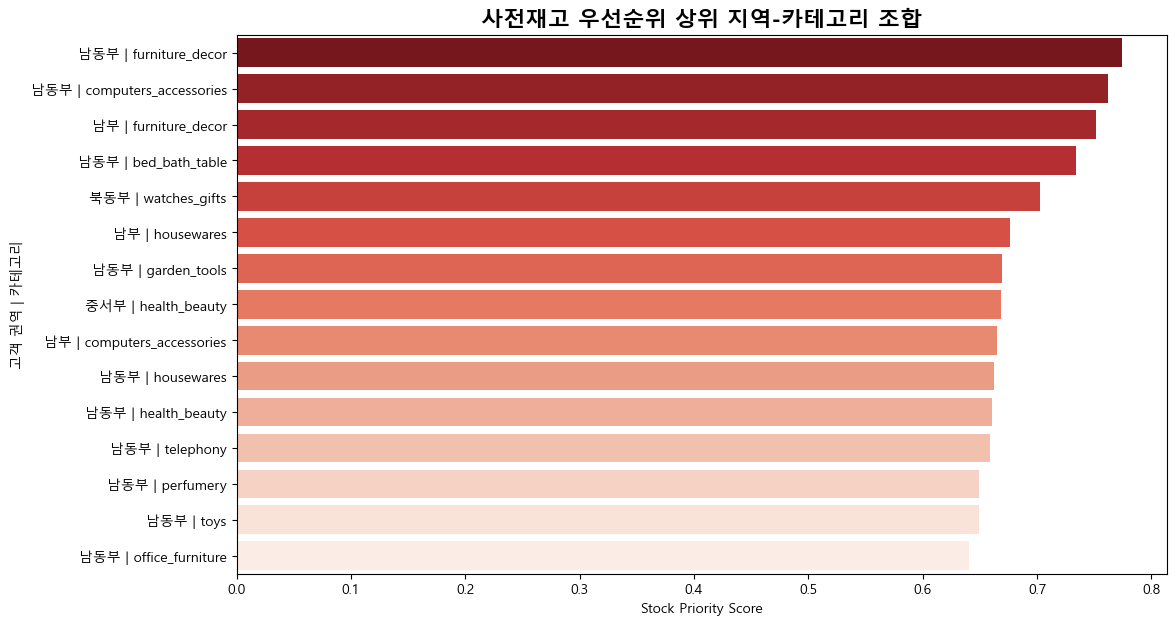

In [9]:
stock_plot = stock_candidates.head(15).copy()
stock_plot["label"] = (
    stock_plot["customer_region"].astype(str) +
    " | " +
    stock_plot["category"].astype(str)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=stock_plot,
    y="label",
    x="stock_priority_score",
    palette="Reds_r"
)

plt.title("사전재고 우선순위 상위 지역-카테고리 조합", fontsize=16, weight="bold")
plt.xlabel("Stock Priority Score")
plt.ylabel("고객 권역 | 카테고리")

plt.show()

## 사전재고 후보 해석

`stock_priority_score`가 높은 조합은 예상 수요가 많고, 배송 지연률이 높으며, 평균 배송기간이 길고, 리뷰점수가 낮은 조합이다.

따라서 해당 조합은 집하장에 사전재고를 배치할 우선 후보로 볼 수 있다.

이 결과는 “어떤 상품을 어느 지역 창고에 미리 보유해야 하는가?”에 대한 데이터 기반 근거가 된다.

# 5. 집하장 보유 재고량 추정

## 분석 목적

집하장 운영을 위해서는 어떤 품목을 보유할지뿐만 아니라, 얼마나 보유해야 하는지도 추정해야 한다.

여기서는 예측 월수요와 과거 수요 변동성을 활용해 권장 보유량을 계산한다.

권장 보유량은 다음과 같이 정의한다.

`권장 보유량 = 예측 월수요 + 1.65 × 월별 수요 표준편차`

여기서 1.65는 약 95% 서비스 수준을 가정한 안전계수이다.

In [10]:
demand_std = monthly_demand.groupby(
    ["customer_region", "category"]
)["monthly_order_count"].std().reset_index()

demand_std = demand_std.rename(columns={
    "monthly_order_count": "monthly_order_std"
})

stock_plan = stock_candidates.merge(
    demand_std,
    on=["customer_region", "category"],
    how="left"
)

stock_plan["monthly_order_std"] = stock_plan["monthly_order_std"].fillna(0)

stock_plan["recommended_stock"] = np.ceil(
    stock_plan["predicted_monthly_order"] +
    1.65 * stock_plan["monthly_order_std"]
)

display(stock_plan[[
    "customer_region",
    "category",
    "predicted_monthly_order",
    "monthly_order_std",
    "recommended_stock",
    "stock_priority_score"
]].head(20))

,customer_region,category,predicted_monthly_order,monthly_order_std,recommended_stock,stock_priority_score
0,남동부,furniture_decor,52.669139,21.654429,89.0,0.774510
1,남동부,computers_accessories,24.363558,21.498776,60.0,0.761765
2,남부,furniture_decor,13.099064,6.786892,25.0,0.751961
3,남동부,bed_bath_table,59.769017,28.749874,108.0,0.734314
4,북동부,watches_gifts,3.399113,0.975900,6.0,0.702941
5,남부,housewares,10.697221,3.413081,17.0,0.676471
6,남동부,garden_tools,20.921531,11.979258,41.0,0.669608
7,중서부,health_beauty,4.429984,2.249183,9.0,0.668627
8,남부,computers_accessories,6.856327,5.065906,16.0,0.664706
9,남동부,housewares,48.211219,15.573329,74.0,0.662745


C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\2571975767.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


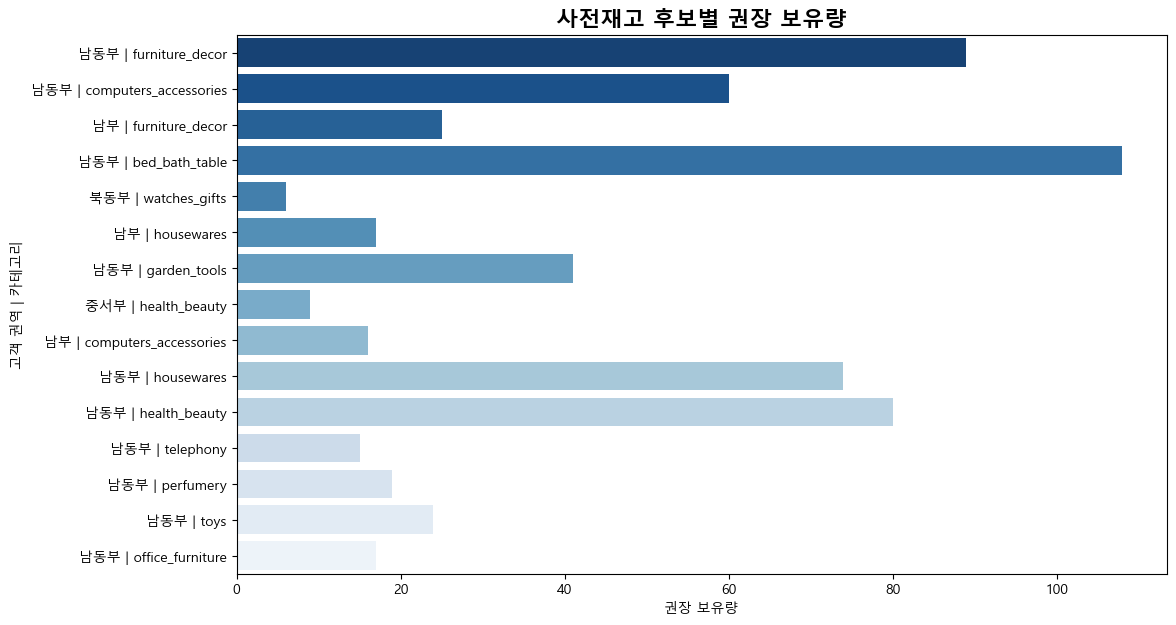

In [11]:
stock_amount_plot = stock_plan.head(15).copy()
stock_amount_plot["label"] = (
    stock_amount_plot["customer_region"].astype(str) +
    " | " +
    stock_amount_plot["category"].astype(str)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=stock_amount_plot,
    y="label",
    x="recommended_stock",
    palette="Blues_r"
)

plt.title("사전재고 후보별 권장 보유량", fontsize=16, weight="bold")
plt.xlabel("권장 보유량")
plt.ylabel("고객 권역 | 카테고리")

plt.show()

## 권장 보유량 해석

권장 보유량은 예상 월수요에 수요 변동성을 반영한 값이다.

수요가 많고 변동성이 큰 카테고리는 더 많은 안전재고가 필요하다.

이 결과는 집하장에 어떤 카테고리를 얼마나 보유해야 하는지에 대한 초기 기준으로 활용할 수 있다.

# 6. 집하장 후보 지역 산정

## 분석 목적

집하장 후보 지역은 단일 카테고리 기준이 아니라, 권역 전체의 수요와 배송 문제를 함께 고려해야 한다.

따라서 권역별로 다음 지표를 종합한다.

1. 예측 주문 수 합계
2. 권장 보유량 합계
3. 평균 배송 지연률
4. 평균 배송기간
5. 평균 리뷰점수
6. 사전재고 후보 카테고리 수

이를 바탕으로 집하장 우선순위 점수를 계산한다.

In [12]:
hub_region_summary = stock_plan.groupby("customer_region").agg(
    predicted_order_sum=("predicted_monthly_order", "sum"),
    recommended_stock_sum=("recommended_stock", "sum"),
    avg_delay_rate=("delay_rate", "mean"),
    avg_delivery_days=("avg_delivery_days", "mean"),
    avg_review_score=("avg_review_score", "mean"),
    category_count=("category", "nunique")
).reset_index()

hub_region_summary["hub_priority_score"] = (
    hub_region_summary["predicted_order_sum"].rank(pct=True) * 0.35 +
    hub_region_summary["avg_delay_rate"].rank(pct=True) * 0.25 +
    hub_region_summary["avg_delivery_days"].rank(pct=True) * 0.20 +
    (1 - hub_region_summary["avg_review_score"].rank(pct=True)) * 0.15 +
    hub_region_summary["category_count"].rank(pct=True) * 0.05
)

hub_region_summary = hub_region_summary.sort_values(
    "hub_priority_score",
    ascending=False
)

display(hub_region_summary)

,customer_region,predicted_order_sum,recommended_stock_sum,avg_delay_rate,avg_delivery_days,avg_review_score,category_count,hub_priority_score
0,남동부,369.333281,654.0,0.109479,6.405806,3.665798,15,0.75
4,중서부,33.595717,63.0,0.057143,9.580519,3.599711,11,0.68
2,북동부,22.418822,46.0,0.040816,11.219728,3.615646,7,0.56
1,남부,73.555760,146.0,0.028983,8.305785,4.212765,14,0.50
3,북부,8.271370,15.0,0.000000,13.800000,3.775000,4,0.36


C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\1070329694.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


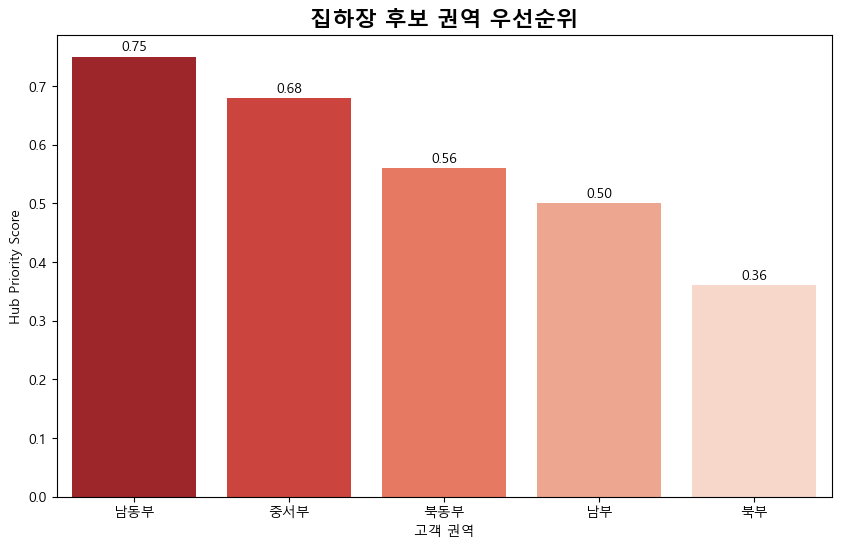

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=hub_region_summary,
    x="customer_region",
    y="hub_priority_score",
    palette="Reds_r"
)

plt.title("집하장 후보 권역 우선순위", fontsize=16, weight="bold")
plt.xlabel("고객 권역")
plt.ylabel("Hub Priority Score")

for i, row in hub_region_summary.reset_index(drop=True).iterrows():
    plt.text(
        i,
        row["hub_priority_score"] + 0.01,
        f'{row["hub_priority_score"]:.2f}',
        ha="center"
    )

plt.show()

## 집하장 후보 지역 해석

`hub_priority_score`가 높은 권역은 다음 특성을 가진다.

- 사전재고 대상 품목의 예상 수요가 많다.
- 배송 지연률이 높다.
- 평균 배송기간이 길다.
- 리뷰점수가 낮다.
- 여러 카테고리에서 사전재고 필요성이 나타난다.

따라서 해당 권역은 다품목 주문 복잡성과 배송 지연 문제를 줄이기 위한 집하장 후보 지역으로 볼 수 있다.

# 7. 예상 평점 상승 효과 추정

## 분석 목적

집하장 운영의 기대 효과는 실제 배송기간 단축과 평점 개선이다.

여기서는 단순 시뮬레이션 방식으로 배송기간이 줄어들었을 때 예상 리뷰점수가 얼마나 상승할 수 있는지 추정한다.

가정은 다음과 같다.

- 집하장 운영으로 다품목 주문의 배송기간이 10%, 20%, 30% 단축된다고 가정한다.
- 기존 데이터에서 배송기간, 상품 개수, 배송비, 주문금액과 리뷰점수의 관계를 학습한다.
- 배송기간만 단축된 상황을 시뮬레이션하여 예상 평점 상승폭을 계산한다.

In [14]:
review_model_df = multi_df.groupby("order_id", as_index=False).agg(
    delivery_days_clean=("delivery_days_clean", "first"),
    item_count=("item_count", "first"),
    freight_total=("freight_value", "sum"),
    price_total=("price", "sum"),
    review_score_mean=("review_score_mean", "first")
).replace([np.inf, -np.inf], np.nan).dropna()

X_review = review_model_df[
    ["delivery_days_clean", "item_count", "freight_total", "price_total"]
]

y_review = review_model_df["review_score_mean"]

rating_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

rating_model.fit(X_review, y_review)

baseline_pred = rating_model.predict(X_review).mean()

uplift_results = []

for reduction in [0.10, 0.20, 0.30]:
    X_sim = X_review.copy()
    X_sim["delivery_days_clean"] = X_sim["delivery_days_clean"] * (1 - reduction)
    
    sim_pred = rating_model.predict(X_sim).mean()
    
    uplift_results.append({
        "delivery_days_reduction": f"{int(reduction * 100)}%",
        "baseline_pred_rating": baseline_pred,
        "simulated_pred_rating": sim_pred,
        "expected_rating_uplift": sim_pred - baseline_pred
    })

uplift_df = pd.DataFrame(uplift_results)

display(uplift_df)

,delivery_days_reduction,baseline_pred_rating,simulated_pred_rating,expected_rating_uplift
0,10%,3.636795,3.678392,0.041597
1,20%,3.636795,3.710885,0.074090
2,30%,3.636795,3.746277,0.109482


C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\679436122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


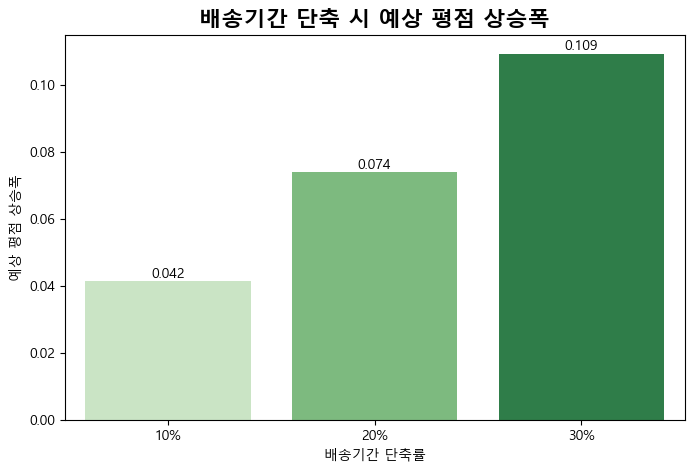

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=uplift_df,
    x="delivery_days_reduction",
    y="expected_rating_uplift",
    palette="Greens"
)

plt.title("배송기간 단축 시 예상 평점 상승폭", fontsize=16, weight="bold")
plt.xlabel("배송기간 단축률")
plt.ylabel("예상 평점 상승폭")

for i, row in uplift_df.iterrows():
    plt.text(
        i,
        row["expected_rating_uplift"] + 0.001,
        f'{row["expected_rating_uplift"]:.3f}',
        ha="center"
    )

plt.show()

## 예상 평점 상승 해석

이 시뮬레이션은 실제 정책 시행 결과가 아니라, 기존 데이터에서 학습한 배송기간과 리뷰점수의 관계를 바탕으로 한 추정치이다.

배송기간 단축률이 커질수록 예상 평점 상승폭이 증가한다면, 집하장 운영을 통한 배송 리드타임 단축이 고객 만족도 개선에 기여할 수 있음을 시사한다.

다만 실제 평점 상승은 배송기간 외에도 상품 품질, 판매자 응대, 가격, 고객 기대 수준 등의 영향을 받으므로, 본 결과는 정책 효과의 방향성을 보는 참고 지표로 해석해야 한다.

# 최종 해석 예시

본 분석은 다품목 주문이 배송 지연 및 평점 하락의 주요 원인으로 나타난 점에 착안하여, 집하장 운영과 사전재고 전략을 검토하였다.

먼저 다품목 주문에 자주 포함되는 주요 카테고리를 파악하고, 해당 카테고리를 많이 필요로 하는 고객 권역을 확인하였다.

이후 지역-카테고리별 월별 수요를 Random Forest 모델로 예측하고, 예상 수요와 과거 수요 변동성을 바탕으로 권장 보유 재고량을 산정하였다.

또한 예상 수요, 배송 지연률, 평균 배송기간, 리뷰점수를 종합하여 집하장 후보 권역의 우선순위를 계산하였다.

마지막으로 집하장 운영으로 배송기간이 단축될 경우 예상 리뷰점수가 얼마나 상승할 수 있는지 시뮬레이션하였다.

분석 결과는 집하장 운영 전략이 단순한 허브 추가가 아니라, 다음 기준을 함께 고려해야 함을 보여준다.

1. 다품목 주문 수요가 많은 지역
2. 다품목 주문에 자주 포함되는 카테고리
3. 배송 지연률이 높은 지역-카테고리 조합
4. 평균 배송기간이 긴 조합
5. 리뷰점수가 낮은 조합
6. 수요 변동성을 고려한 권장 보유량

따라서 집하장은 고수요·고지연 다품목 카테고리를 주요 고객 권역에 사전 배치하여, 실제 배송 리드타임과 주문 처리 복잡성을 줄이는 방향으로 운영하는 것이 적절하다.

---

수요예측 모델 비교
RandomForest / ExtraTrees / GradientBoosting / HistGradientBoosting / XGBoost 가능 시 사용
→ 가장 성능 좋은 모델 선택
→ 주-카테고리별 예상 판매량/재고량 산정
→ 기대효과 계산
→ 고객/판매자 위치 기반 집하장 후보 생성
→ 주/도시별 후보와 기대효과 연결

# 추가 분석. 모델 비교 기반 사전재고 수요예측과 집하장 거점 선정

## 분석 목적

본 분석은 사전재고 운영을 위해 주-카테고리별 예상 판매량을 예측하고, 그 결과를 집하장 후보 선정에 연결한다.

기존 Random Forest만 사용하는 방식에서 확장하여 여러 회귀 모델을 비교한다.

사용 모델은 다음과 같다.

- Random Forest
- Extra Trees
- Gradient Boosting
- HistGradientBoosting

최종적으로 가장 성능이 좋은 모델을 사용하여 예상 판매량, 권장 보유량, 기대 매출, 지연 감소 효과를 계산하고, 고객/판매자 위치 기반 집하장 후보 도시를 선정한다.

In [38]:
from pathlib import Path

ROOT = Path.cwd()

while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

OUTPUT_DIR = (
    ROOT
    / "notebooks"
    / "Distribution_hub"
    / "HY"
    / "Logistics_folder"
    / "outputs"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("저장 경로:", OUTPUT_DIR)

model_compare.to_csv(
    OUTPUT_DIR / "demand_model_comparison_without_xgboost.csv",
    index=False,
    encoding="utf-8-sig"
)

state_stock_plan.to_csv(
    OUTPUT_DIR / "state_category_stock_plan_with_best_sklearn_model.csv",
    index=False,
    encoding="utf-8-sig"
)

state_expected_effect.to_csv(
    OUTPUT_DIR / "state_inventory_expected_effect.csv",
    index=False,
    encoding="utf-8-sig"
)

region_hub_candidates.to_csv(
    OUTPUT_DIR / "region_hub_candidates_with_business_effect.csv",
    index=False,
    encoding="utf-8-sig"
)

final_hub_by_region.to_csv(
    OUTPUT_DIR / "final_hub_by_region_with_inventory_effect.csv",
    index=False,
    encoding="utf-8-sig"
)

top_category_by_selected_state.to_csv(
    OUTPUT_DIR / "final_hub_stock_category_plan.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료")
print(OUTPUT_DIR)

저장 경로: c:\Users\yiho1\포트폴리오 프로젝트\team-oldest-olist-analysis\notebooks\Distribution_hub\HY\Logistics_folder\outputs
저장 완료
c:\Users\yiho1\포트폴리오 프로젝트\team-oldest-olist-analysis\notebooks\Distribution_hub\HY\Logistics_folder\outputs


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.cluster import KMeans

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

def minmax(series):
    s = pd.to_numeric(series, errors="coerce").astype(float)
    if s.isna().all():
        return pd.Series(0.5, index=s.index)
    s = s.fillna(s.median())
    if s.max() == s.min():
        return pd.Series(0.5, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

XGBoost 사용 가능 여부: False


## 1. 주-카테고리별 월별 수요 데이터 생성

권역 단위가 아니라 주 단위로 예상 판매량과 권장 보유량을 계산한다.

주 단위 분석을 수행하면 어느 주에 어떤 카테고리를 사전재고로 보유해야 하는지 더 구체적으로 판단할 수 있다.

In [22]:
state_monthly_demand = (
    multi_top_df
    .groupby(["purchase_month_date", "customer_region", "customer_state", "category"], as_index=False)
    .agg(
        monthly_order_count=("order_id", "nunique"),
        monthly_item_count=("order_item_id", "count"),
        avg_order_value=("payment_value_total", "mean"),
        avg_delivery_days=("delivery_days_clean", "mean"),
        delay_rate=("is_delay", "mean"),
        avg_review_score=("review_score_mean", "mean"),
        avg_item_count=("item_count", "mean")
    )
)

state_monthly_demand["month"] = state_monthly_demand["purchase_month_date"].dt.month
state_monthly_demand["year"] = state_monthly_demand["purchase_month_date"].dt.year

state_monthly_demand = state_monthly_demand.sort_values(
    ["customer_state", "category", "purchase_month_date"]
).copy()

group_cols = ["customer_state", "category"]

state_monthly_demand["lag_1_order"] = state_monthly_demand.groupby(group_cols)["monthly_order_count"].shift(1)
state_monthly_demand["lag_2_order"] = state_monthly_demand.groupby(group_cols)["monthly_order_count"].shift(2)
state_monthly_demand["lag_3_order"] = state_monthly_demand.groupby(group_cols)["monthly_order_count"].shift(3)

state_monthly_demand["rolling_3_order"] = state_monthly_demand[
    ["lag_1_order", "lag_2_order", "lag_3_order"]
].mean(axis=1)

state_model_df = state_monthly_demand.dropna(subset=[
    "lag_1_order",
    "lag_2_order",
    "lag_3_order",
    "rolling_3_order"
]).copy()

print("모델 학습 데이터:", state_model_df.shape)
display(state_model_df.head())

모델 학습 데이터: (1505, 17)


,purchase_month_date,customer_region,customer_state,category,monthly_order_count,monthly_item_count,avg_order_value,avg_delivery_days,delay_rate,avg_review_score,avg_item_count,month,year,lag_1_order,lag_2_order,lag_3_order,rolling_3_order
1496,2018-02-01,북동부,AL,computers_accessories,1,2,132.1000,36.0000,0.0000,1.0000,2.0000,2,2018,1.0000,1.0000,1.0000,1.0000
1633,2018-03-01,북동부,AL,computers_accessories,1,2,135.7400,11.0000,0.0000,3.0000,2.0000,3,2018,1.0000,1.0000,1.0000,1.0000
1218,2017-12-01,북동부,BA,auto,1,3,177.8700,27.0000,0.0000,5.0000,3.0000,12,2017,1.0000,1.0000,1.0000,1.0000
1635,2018-03-01,북동부,BA,auto,2,4,255.9400,19.5000,0.0000,4.5000,2.0000,3,2018,1.0000,1.0000,1.0000,1.0000
1777,2018-04-01,북동부,BA,auto,1,2,161.0200,22.0000,0.0000,3.0000,2.0000,4,2018,2.0000,1.0000,1.0000,1.3333


## 2. 수요예측 모델 비교

다음 4개 회귀 모델을 비교한다.

| 모델 | 특징 |
|---|---|
| RandomForest | 여러 의사결정나무를 평균내는 안정적인 앙상블 모델 |
| ExtraTrees | 분할 기준을 더 무작위화하여 분산을 줄이는 앙상블 모델 |
| GradientBoosting | 이전 모델의 오차를 순차적으로 보완하는 부스팅 모델 |
| HistGradientBoosting | 대용량 데이터에 효율적인 scikit-learn 부스팅 모델 |

최종 모델은 RMSE가 가장 낮은 모델로 선택한다.

In [24]:
feature_cols = [
    "year",
    "month",
    "lag_1_order",
    "lag_2_order",
    "lag_3_order",
    "rolling_3_order",
    "avg_delivery_days",
    "delay_rate",
    "avg_review_score",
    "avg_item_count",
    "avg_order_value"
]

cat_cols = [
    "customer_region",
    "customer_state",
    "category"
]

model_input_df = state_model_df[feature_cols + cat_cols + ["monthly_order_count"]].copy()

# 숫자형 결측치 처리
for col in feature_cols:
    model_input_df[col] = pd.to_numeric(model_input_df[col], errors="coerce")
    model_input_df[col] = model_input_df[col].fillna(model_input_df[col].median())

# 범주형 결측치 처리
for col in cat_cols:
    model_input_df[col] = model_input_df[col].astype("object").fillna("unknown")

X = pd.get_dummies(
    model_input_df[feature_cols + cat_cols],
    columns=cat_cols,
    drop_first=False
)

y = model_input_df["monthly_order_count"]

# 혹시 남아 있는 NaN 최종 확인
print("X NaN 개수:", X.isna().sum().sum())
print("y NaN 개수:", y.isna().sum())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300,
        max_leaf_nodes=31,
        learning_rate=0.05,
        random_state=42
    )
}

model_results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    
    model_results.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    
    trained_models[model_name] = model

model_compare = pd.DataFrame(model_results).sort_values("RMSE")

display(model_compare)

best_model_name = model_compare.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("최종 선택 모델:", best_model_name)

X NaN 개수: 0
y NaN 개수: 0


,model,MAE,RMSE,R2
2,GradientBoosting,1.3862,2.6944,0.8413
0,RandomForest,1.5311,3.0109,0.8018
3,HistGradientBoosting,1.4721,3.0153,0.8013
1,ExtraTrees,1.6959,3.1292,0.7860


최종 선택 모델: GradientBoosting


## 3. 최종 모델로 주-카테고리별 예상 판매량 산정

가장 최근 월 데이터를 기준으로 다음 월 수요를 예측한다.

예측값은 음수가 될 수 없으므로 0 이상으로 보정한다.

In [42]:
latest_month = state_monthly_demand["purchase_month_date"].max()

state_latest_df = state_monthly_demand[
    state_monthly_demand["purchase_month_date"].eq(latest_month)
].copy()

state_latest_df = state_latest_df.dropna(subset=[
    "lag_1_order",
    "lag_2_order",
    "lag_3_order",
    "rolling_3_order"
]).copy()

latest_input_df = state_latest_df[feature_cols + cat_cols].copy()

for col in feature_cols:
    latest_input_df[col] = pd.to_numeric(latest_input_df[col], errors="coerce")
    latest_input_df[col] = latest_input_df[col].fillna(model_input_df[col].median())

for col in cat_cols:
    latest_input_df[col] = latest_input_df[col].astype("object").fillna("unknown")

X_latest = pd.get_dummies(
    latest_input_df,
    columns=cat_cols,
    drop_first=False
)

X_latest = X_latest.reindex(columns=X.columns, fill_value=0)

state_latest_df["predicted_monthly_order"] = best_model.predict(X_latest)
state_latest_df["predicted_monthly_order"] = state_latest_df["predicted_monthly_order"].clip(lower=0)

demand_std = (
    state_monthly_demand
    .groupby(["customer_region", "customer_state", "category"])["monthly_order_count"]
    .std()
    .reset_index()
    .rename(columns={"monthly_order_count": "monthly_order_std"})
)

state_stock_plan = state_latest_df.merge(
    demand_std,
    on=["customer_region", "customer_state", "category"],
    how="left"
)

state_stock_plan["monthly_order_std"] = state_stock_plan["monthly_order_std"].fillna(0)

state_stock_plan["recommended_stock"] = np.ceil(
    state_stock_plan["predicted_monthly_order"]
    + 1.65 * state_stock_plan["monthly_order_std"]
)

state_stock_plan["expected_revenue"] = (
    state_stock_plan["predicted_monthly_order"]
    * state_stock_plan["avg_order_value"]
)

state_stock_plan = state_stock_plan.sort_values(
    "predicted_monthly_order",
    ascending=False
)

display(state_stock_plan[[
    "customer_region",
    "customer_state",
    "category",
    "predicted_monthly_order",
    "recommended_stock",
    "avg_order_value",
    "expected_revenue",
    "delay_rate",
    "avg_delivery_days",
    "avg_review_score"
]].tail(100))

,customer_region,customer_state,category,predicted_monthly_order,recommended_stock,avg_order_value,expected_revenue,delay_rate,avg_delivery_days,avg_review_score
93,남동부,SP,auto,9.8095,15.0000,108.3639,"1,062.9978",0.1111,5.0556,3.6667
75,남부,RS,furniture_decor,9.7110,15.0000,285.7868,"2,775.2861",0.0526,10.4211,3.5263
106,남동부,SP,toys,9.5370,16.0000,399.8695,"3,813.5480",0.1579,4.8947,3.9474
61,남동부,RJ,bed_bath_table,8.6285,20.0000,145.7129,"1,257.2780",0.0000,6.4286,3.7143
65,남동부,RJ,housewares,8.1996,14.0000,262.2815,"2,150.5914",0.1538,7.0000,3.5385
107,남동부,SP,watches_gifts,7.8173,15.0000,183.7290,"1,436.2689",0.0000,3.2000,4.2500
102,남동부,SP,perfumery,7.0815,13.0000,232.7254,"1,648.0375",0.1538,5.6923,3.0000
104,남동부,SP,stationery,7.0283,12.0000,118.5700,833.3489,0.5714,6.8571,4.4286
64,남동부,RJ,health_beauty,6.9410,12.0000,212.0444,"1,471.8062",0.0000,5.9375,3.3750
25,남동부,MG,bed_bath_table,6.8992,15.0000,239.8970,"1,655.0880",0.0000,6.6522,3.3478


## 4. 사전재고 운영 기대효과 산정

사전재고 운영의 기대효과를 다음 지표로 계산한다.

- 예상 판매량
- 권장 보유량
- 예상 매출
- 예상 추가 주문 수
- 예상 추가 매출
- 예상 지연 감소 주문 수
- 예상 리뷰점수 개선

세 가지 시나리오를 사용한다.

| 시나리오 | 지연 감소율 | 리뷰 개선폭 | 주문 증가율 |
|---|---:|---:|---:|
| 보수적 | 10% | 0.03점 | 1% |
| 기준 | 20% | 0.06점 | 2% |
| 낙관적 | 30% | 0.10점 | 3% |

In [43]:
effect_scenarios = pd.DataFrame([
    {
        "scenario": "보수적",
        "delay_reduction_rate": 0.10,
        "review_score_uplift": 0.03,
        "order_growth_rate": 0.01
    },
    {
        "scenario": "기준",
        "delay_reduction_rate": 0.20,
        "review_score_uplift": 0.06,
        "order_growth_rate": 0.02
    },
    {
        "scenario": "낙관적",
        "delay_reduction_rate": 0.30,
        "review_score_uplift": 0.10,
        "order_growth_rate": 0.03
    }
])

state_base_effect = (
    state_stock_plan
    .groupby(["customer_region", "customer_state"], as_index=False)
    .agg(
        predicted_order_sum=("predicted_monthly_order", "sum"),
        recommended_stock_sum=("recommended_stock", "sum"),
        expected_revenue_sum=("expected_revenue", "sum"),
        avg_order_value=("avg_order_value", "mean"),
        avg_delay_rate=("delay_rate", "mean"),
        avg_delivery_days=("avg_delivery_days", "mean"),
        avg_review_score=("avg_review_score", "mean"),
        category_count=("category", "nunique")
    )
)

state_base_effect["expected_delay_orders"] = (
    state_base_effect["predicted_order_sum"]
    * state_base_effect["avg_delay_rate"]
)

effect_rows = []

for _, scenario in effect_scenarios.iterrows():
    temp = state_base_effect.copy()
    temp["scenario"] = scenario["scenario"]
    temp["delay_reduction_rate"] = scenario["delay_reduction_rate"]
    temp["review_score_uplift"] = scenario["review_score_uplift"]
    temp["order_growth_rate"] = scenario["order_growth_rate"]
    
    temp["expected_prevented_delay_orders"] = (
        temp["expected_delay_orders"] * temp["delay_reduction_rate"]
    )
    
    temp["expected_additional_orders"] = (
        temp["predicted_order_sum"] * temp["order_growth_rate"]
    )
    
    temp["expected_order_after_effect"] = (
        temp["predicted_order_sum"] + temp["expected_additional_orders"]
    )
    
    temp["expected_additional_revenue"] = (
        temp["expected_additional_orders"] * temp["avg_order_value"]
    )
    
    temp["expected_revenue_after_effect"] = (
        temp["expected_revenue_sum"] + temp["expected_additional_revenue"]
    )
    
    temp["expected_review_score_after_effect"] = (
        temp["avg_review_score"] + temp["review_score_uplift"]
    ).clip(upper=5)
    
    effect_rows.append(temp)

state_expected_effect = pd.concat(effect_rows, ignore_index=True)

baseline_effect = state_expected_effect[
    state_expected_effect["scenario"].eq("기준")
].copy()

baseline_effect = baseline_effect.sort_values(
    "expected_additional_revenue",
    ascending=False
)

display(baseline_effect[[
    "customer_region",
    "customer_state",
    "predicted_order_sum",
    "recommended_stock_sum",
    "expected_revenue_sum",
    "expected_additional_orders",
    "expected_additional_revenue",
    "expected_prevented_delay_orders",
    "avg_delivery_days",
    "avg_delay_rate",
    "avg_review_score",
    "expected_review_score_after_effect",
    "category_count"
]].head(50))

,customer_region,customer_state,predicted_order_sum,recommended_stock_sum,expected_revenue_sum,expected_additional_orders,expected_additional_revenue,expected_prevented_delay_orders,avg_delivery_days,avg_delay_rate,avg_review_score,expected_review_score_after_effect,category_count
19,남동부,SP,236.1997,418.0000,"52,557.6879",4.7240,"1,072.4707",6.3603,5.7997,0.1346,3.8231,3.8831,15
17,남동부,MG,41.9139,103.0000,"12,521.6702",0.8383,277.3325,0.3224,7.6881,0.0385,3.7903,3.8503,13
18,남동부,RJ,55.4635,112.0000,"11,115.8401",1.1093,235.7411,0.2613,7.3935,0.0236,3.1768,3.2368,11
21,남부,RS,33.3283,65.0000,"9,940.8556",0.6666,212.9908,0.1302,7.5619,0.0195,4.2131,4.2731,12
20,남부,PR,27.9211,61.0000,"5,689.1086",0.5584,99.9121,0.0955,6.9805,0.0171,4.0372,4.0972,13
22,남부,SC,19.8391,42.0000,"4,171.8150",0.3968,82.1452,0.3968,10.3742,0.1000,4.1131,4.1731,10
29,중서부,GO,8.6974,18.0000,"3,096.9157",0.1739,69.8479,0.2087,10.0300,0.1200,4.5000,4.5600,5
28,중서부,DF,9.6483,21.0000,"3,369.1659",0.1930,65.9023,0.0000,7.8929,0.0000,3.2143,3.2743,7
27,북부,PA,2.5537,5.0000,"1,988.6452",0.0511,40.8263,0.0000,11.5000,0.0000,3.0000,3.0600,2
26,북동부,PE,5.4132,10.0000,"1,713.6656",0.1083,37.6715,0.1444,12.7333,0.1333,2.2667,2.3267,3


## 5. 집하장 후보 생성을 위한 고객/판매자 포인트 생성

집하장 후보는 고객 수요 위치와 판매자 공급 위치를 함께 고려한다.

후보 생성 단계에서는 가중치를 사용하지 않고, 지리적 분포 기반 K-Means로 후보 도시를 탐색한다.

In [30]:
order_first_cols = [
    "customer_unique_id",
    "customer_state",
    "customer_region",
    "customer_city",
    "customer_zip_code_prefix",
    "customer_geo_lat",
    "customer_geo_lng",
    "delivery_days_clean",
    "delivery_vs_estimated_days",
    "is_late",
    "review_score_mean",
]

order_first_cols = [col for col in order_first_cols if col in df.columns]

order_df = (
    df.groupby("order_id", as_index=False)
    .agg({col: "first" for col in order_first_cols})
)

target_states = df["customer_state"].dropna().unique().tolist()

customer_points = (
    order_df[order_df["customer_state"].isin(target_states)]
    .dropna(subset=["customer_geo_lat", "customer_geo_lng"])
    .groupby(
        ["customer_state", "customer_region", "customer_zip_code_prefix", "customer_city"],
        as_index=False
    )
    .agg(
        lat=("customer_geo_lat", "mean"),
        lng=("customer_geo_lng", "mean"),
        customer_orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique"),
        avg_delivery_days=("delivery_days_clean", "mean"),
        late_rate=("is_late", "mean"),
        avg_review_score=("review_score_mean", "mean")
    )
    .rename(columns={
        "customer_state": "state",
        "customer_region": "region",
        "customer_zip_code_prefix": "zip_code_prefix",
        "customer_city": "city"
    })
)

customer_points["point_role"] = "customer_demand"

seller_filter = df["seller_state"].isin(target_states)

if "is_seller_geo_unreliable" in df.columns:
    seller_filter &= ~df["is_seller_geo_unreliable"].fillna(False)

if "seller_state_geo_mismatch" in df.columns:
    seller_filter &= ~df["seller_state_geo_mismatch"].fillna(False)

if "seller_geo_state" in df.columns:
    seller_filter &= df["seller_geo_state"].eq(df["seller_state"])

seller_points = (
    df[seller_filter]
    .dropna(subset=["seller_geo_lat", "seller_geo_lng"])
    .groupby(
        ["seller_state", "seller_region", "seller_zip_code_prefix", "seller_city"],
        as_index=False
    )
    .agg(
        lat=("seller_geo_lat", "mean"),
        lng=("seller_geo_lng", "mean"),
        seller_orders=("order_id", "nunique"),
        sellers=("seller_id", "nunique")
    )
    .rename(columns={
        "seller_state": "state",
        "seller_region": "region",
        "seller_zip_code_prefix": "zip_code_prefix",
        "seller_city": "city"
    })
)

seller_points["point_role"] = "seller_supply"

print("고객 포인트:", len(customer_points))
print("판매자 포인트:", len(seller_points))

고객 포인트: 14731
판매자 포인트: 2169


## 6. 무가중 K-Means 기반 주/도시 집하장 후보 생성

주별 주문 수에 따라 후보 거점 수를 다르게 설정한다.

- 500건 이하: 1개
- 501~1,500건: 2개
- 1,500건 초과: 3개

후보 중심점은 실제 고객 수요 포인트 중 중심에 가장 가까운 도시로 스냅한다.

In [31]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    return 6_371 * 2 * np.arcsin(np.sqrt(a))

def choose_k(order_count):
    if order_count <= 500:
        return 1
    if order_count <= 1500:
        return 2
    return 3

common_cols = [
    "state", "region", "zip_code_prefix", "city",
    "lat", "lng", "point_role"
]

customer_common = customer_points.assign(
    seller_orders=0,
    sellers=0
)[
    common_cols + [
        "customer_orders",
        "customers",
        "avg_delivery_days",
        "late_rate",
        "avg_review_score",
        "seller_orders",
        "sellers"
    ]
]

seller_common = seller_points.assign(
    customer_orders=0,
    customers=0,
    avg_delivery_days=np.nan,
    late_rate=np.nan,
    avg_review_score=np.nan
)[
    common_cols + [
        "customer_orders",
        "customers",
        "avg_delivery_days",
        "late_rate",
        "avg_review_score",
        "seller_orders",
        "sellers"
    ]
]

hub_points = pd.concat([customer_common, seller_common], ignore_index=True)

state_order_map = (
    order_df.groupby("customer_state")["order_id"]
    .nunique()
    .to_dict()
)

clustered_frames = []
hub_rows = []

for state in target_states:
    points = hub_points[hub_points["state"].eq(state)].copy().reset_index(drop=True)
    
    if points.empty:
        continue
    
    k = min(choose_k(state_order_map.get(state, 0)), len(points))
    coords = points[["lat", "lng"]].to_numpy()
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    points["hub_cluster"] = model.fit_predict(coords)
    centers = model.cluster_centers_
    
    for cluster_id in range(k):
        cluster_points = points[points["hub_cluster"].eq(cluster_id)].copy()
        center_lat, center_lng = centers[cluster_id]
        
        cluster_points["distance_to_center_km"] = haversine_km(
            cluster_points["lat"],
            cluster_points["lng"],
            center_lat,
            center_lng
        )
        
        customer_cluster = cluster_points[
            cluster_points["point_role"].eq("customer_demand")
        ].copy()
        
        if len(customer_cluster) > 0:
            nearest = customer_cluster.sort_values("distance_to_center_km").iloc[0]
        else:
            nearest = cluster_points.sort_values("distance_to_center_km").iloc[0]
        
        hub_rows.append({
            "state": state,
            "region": nearest["region"],
            "suggested_city": nearest["city"],
            "suggested_zip_code_prefix": nearest["zip_code_prefix"],
            "hub_lat": nearest["lat"],
            "hub_lng": nearest["lng"],
            "cluster_id": cluster_id,
            "covered_customer_orders": cluster_points["customer_orders"].sum(),
            "covered_customers": cluster_points["customers"].sum(),
            "covered_seller_orders": cluster_points["seller_orders"].sum(),
            "covered_sellers": cluster_points["sellers"].sum(),
            "avg_delivery_days": customer_cluster["avg_delivery_days"].mean(),
            "late_rate": customer_cluster["late_rate"].mean(),
            "avg_review_score": customer_cluster["avg_review_score"].mean(),
            "avg_distance_to_hub_km": cluster_points["distance_to_center_km"].mean()
        })
    
    clustered_frames.append(points)

hub_candidate_points = pd.concat(clustered_frames, ignore_index=True)
hub_candidates = pd.DataFrame(hub_rows)

display(hub_candidates.head())

,state,region,suggested_city,suggested_zip_code_prefix,hub_lat,hub_lng,cluster_id,covered_customer_orders,covered_customers,covered_seller_orders,covered_sellers,avg_delivery_days,late_rate,avg_review_score,avg_distance_to_hub_km
0,RJ,남동부,glicerio,27985,-22.2369,-42.0623,0,1528,1481,194,17,18.2768,0.2092,3.8209,65.4762
1,RJ,남동부,portela,28595,-15.3072,-38.8505,1,6,5,0,0,42.5000,0.7500,3.0833,351.4166
2,RJ,남동부,mesquita,26564,-22.7733,-43.4178,2,10663,10323,3982,146,15.1077,0.1425,3.8940,35.3186
3,SP,남동부,sao paulo,2013,-23.5022,-46.6331,0,32748,31728,47319,1281,7.9376,0.0632,4.2307,29.7173
4,SP,남동부,brauna,16290,-21.5043,-50.3223,1,2602,2542,4491,139,10.0393,0.0438,4.3165,109.5875


## 7. 주별 기대효과와 집하장 후보 연결

집하장 후보에 해당 주의 예상 판매량, 권장 보유량, 예상 추가 매출, 지연 감소 효과를 연결한다.

최종 후보는 단일 가중치 점수로 결정하지 않고, 주요 비즈니스 기대효과 지표를 함께 비교한다.

In [32]:
hub_candidates = hub_candidates.merge(
    baseline_effect[[
        "customer_state",
        "predicted_order_sum",
        "recommended_stock_sum",
        "expected_revenue_sum",
        "expected_additional_orders",
        "expected_additional_revenue",
        "expected_prevented_delay_orders",
        "expected_review_score_after_effect"
    ]],
    left_on="state",
    right_on="customer_state",
    how="left"
)

hub_candidates["candidate_rank_in_region"] = (
    hub_candidates
    .sort_values(
        ["region", "expected_additional_revenue", "predicted_order_sum", "covered_customer_orders"],
        ascending=[True, False, False, False]
    )
    .groupby("region")
    .cumcount() + 1
)

region_hub_candidates = hub_candidates.sort_values(
    ["region", "candidate_rank_in_region"]
)

display(region_hub_candidates[[
    "region",
    "candidate_rank_in_region",
    "state",
    "suggested_city",
    "suggested_zip_code_prefix",
    "predicted_order_sum",
    "recommended_stock_sum",
    "expected_revenue_sum",
    "expected_additional_revenue",
    "expected_prevented_delay_orders",
    "covered_customer_orders",
    "covered_seller_orders",
    "avg_delivery_days",
    "late_rate",
    "avg_review_score",
    "avg_distance_to_hub_km"
]])

,region,candidate_rank_in_region,state,suggested_city,suggested_zip_code_prefix,predicted_order_sum,recommended_stock_sum,expected_revenue_sum,expected_additional_revenue,expected_prevented_delay_orders,covered_customer_orders,covered_seller_orders,avg_delivery_days,late_rate,avg_review_score,avg_distance_to_hub_km
3,남동부,1,SP,sao paulo,2013,236.1997,418.0000,"52,557.6879","1,072.4707",6.3603,32748,47319,7.9376,0.0632,4.2307,29.7173
5,남동부,2,SP,araraquara,14808,236.1997,418.0000,"52,557.6879","1,072.4707",6.3603,4538,15725,9.6142,0.0468,4.2755,105.3812
4,남동부,3,SP,brauna,16290,236.1997,418.0000,"52,557.6879","1,072.4707",6.3603,2602,4491,10.0393,0.0438,4.3165,109.5875
6,남동부,4,MG,itabirito,35450,41.9139,103.0000,"12,521.6702",277.3325,0.3224,7312,4223,11.6219,0.0600,4.1683,95.0080
7,남동부,5,MG,delfinopolis,37910,41.9139,103.0000,"12,521.6702",277.3325,0.3224,2698,3326,12.2321,0.0635,4.2333,189.6791
8,남동부,6,MG,turmalina,39660,41.9139,103.0000,"12,521.6702",277.3325,0.3224,1167,29,13.4406,0.0733,4.2448,196.6066
2,남동부,7,RJ,mesquita,26564,55.4635,112.0000,"11,115.8401",235.7411,0.2613,10663,3982,15.1077,0.1425,3.8940,35.3186
0,남동부,8,RJ,glicerio,27985,55.4635,112.0000,"11,115.8401",235.7411,0.2613,1528,194,18.2768,0.2092,3.8209,65.4762
1,남동부,9,RJ,portela,28595,55.4635,112.0000,"11,115.8401",235.7411,0.2613,6,0,42.5000,0.7500,3.0833,351.4166
34,남동부,10,ES,araguaia,29258,3.8914,7.0000,"1,563.8602",32.2673,0.0000,1634,305,15.8992,0.1487,4.0531,47.3467


## 8. 권역별 최종 집하장 후보 선정

권역별 최종 후보는 다음 기준으로 선정한다.

1. 예상 추가 매출이 큰 후보
2. 예상 판매량이 큰 후보
3. 커버 고객 주문 수가 많은 후보
4. 평균 커버 거리가 과도하게 크지 않은 후보

이 방식은 별도 가중치 없이 비즈니스 기대효과 중심으로 후보를 정렬하는 방식이다.

In [33]:
final_hub_by_region = (
    region_hub_candidates
    .sort_values(
        [
            "region",
            "expected_additional_revenue",
            "predicted_order_sum",
            "covered_customer_orders",
            "avg_distance_to_hub_km"
        ],
        ascending=[True, False, False, False, True]
    )
    .groupby("region", as_index=False)
    .head(1)
)

display(final_hub_by_region[[
    "region",
    "state",
    "suggested_city",
    "suggested_zip_code_prefix",
    "predicted_order_sum",
    "recommended_stock_sum",
    "expected_revenue_sum",
    "expected_additional_revenue",
    "expected_prevented_delay_orders",
    "covered_customer_orders",
    "covered_seller_orders",
    "avg_delivery_days",
    "late_rate",
    "avg_review_score",
    "avg_distance_to_hub_km"
]])

,region,state,suggested_city,suggested_zip_code_prefix,predicted_order_sum,recommended_stock_sum,expected_revenue_sum,expected_additional_revenue,expected_prevented_delay_orders,covered_customer_orders,covered_seller_orders,avg_delivery_days,late_rate,avg_review_score,avg_distance_to_hub_km
3,남동부,SP,sao paulo,2013,236.1997,418.0000,"52,557.6879","1,072.4707",6.3603,32748,47319,7.9376,0.0632,4.2307,29.7173
26,남부,RS,portao,93180,33.3283,65.0000,"9,940.8556",212.9908,0.1302,3543,1754,15.1172,0.0802,4.1335,54.7989
45,북동부,PE,camaragibe,54767,5.4132,10.0000,"1,713.6656",37.6715,0.1444,1129,355,18.7768,0.1246,4.0000,23.1827
37,북부,PA,quatro bocas,68682,2.5537,5.0000,"1,988.6452",40.8263,0.0000,932,0,24.4072,0.1398,3.8318,274.1671
14,중서부,GO,aparecida de goiania,74921,8.6974,18.0000,"3,096.9157",69.8479,0.2087,1281,395,15.5207,0.1012,4.0739,48.2254


## 9. 최종 집하장별 우선 적재 카테고리

선정된 집하장 권역/주에 대해 우선 적재할 카테고리를 확인한다.

In [34]:
top_n = 5

top_category_by_selected_state = (
    state_stock_plan[
        state_stock_plan["customer_state"].isin(final_hub_by_region["state"])
    ]
    .sort_values(
        ["customer_state", "predicted_monthly_order"],
        ascending=[True, False]
    )
    .groupby("customer_state", as_index=False)
    .head(top_n)
    .copy()
)

top_category_by_selected_state = top_category_by_selected_state.merge(
    final_hub_by_region[["state", "region", "suggested_city"]],
    left_on="customer_state",
    right_on="state",
    how="left"
)

display(top_category_by_selected_state[[
    "region",
    "customer_state",
    "suggested_city",
    "category",
    "predicted_monthly_order",
    "recommended_stock",
    "expected_revenue",
    "delay_rate",
    "avg_delivery_days",
    "avg_review_score"
]])

,region,customer_state,suggested_city,category,predicted_monthly_order,recommended_stock,expected_revenue,delay_rate,avg_delivery_days,avg_review_score
0,중서부,GO,aparecida de goiania,bed_bath_table,3.6782,7.0000,651.8935,0.0000,9.7500,3.5000
1,중서부,GO,aparecida de goiania,telephony,1.4033,2.0000,630.7419,0.0000,10.0000,4.0000
2,중서부,GO,aparecida de goiania,housewares,1.3744,3.0000,"1,465.2671",0.0000,10.0000,5.0000
3,중서부,GO,aparecida de goiania,sports_leisure,1.2142,3.0000,165.6005,0.6000,7.4000,5.0000
4,중서부,GO,aparecida de goiania,health_beauty,1.0272,3.0000,183.4126,0.0000,13.0000,5.0000
5,북부,PA,quatro bocas,auto,1.3255,3.0000,341.2020,0.0000,15.0000,4.0000
6,북부,PA,quatro bocas,furniture_decor,1.2283,2.0000,"1,647.4432",0.0000,8.0000,2.0000
7,북동부,PE,camaragibe,watches_gifts,2.4482,4.0000,421.1539,0.4000,14.2000,2.8000
8,북동부,PE,camaragibe,furniture_decor,1.7569,4.0000,765.8842,0.0000,12.0000,2.0000
9,북동부,PE,camaragibe,garden_tools,1.2081,2.0000,526.6276,0.0000,12.0000,2.0000


## 10. 시각화

C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\1432405591.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


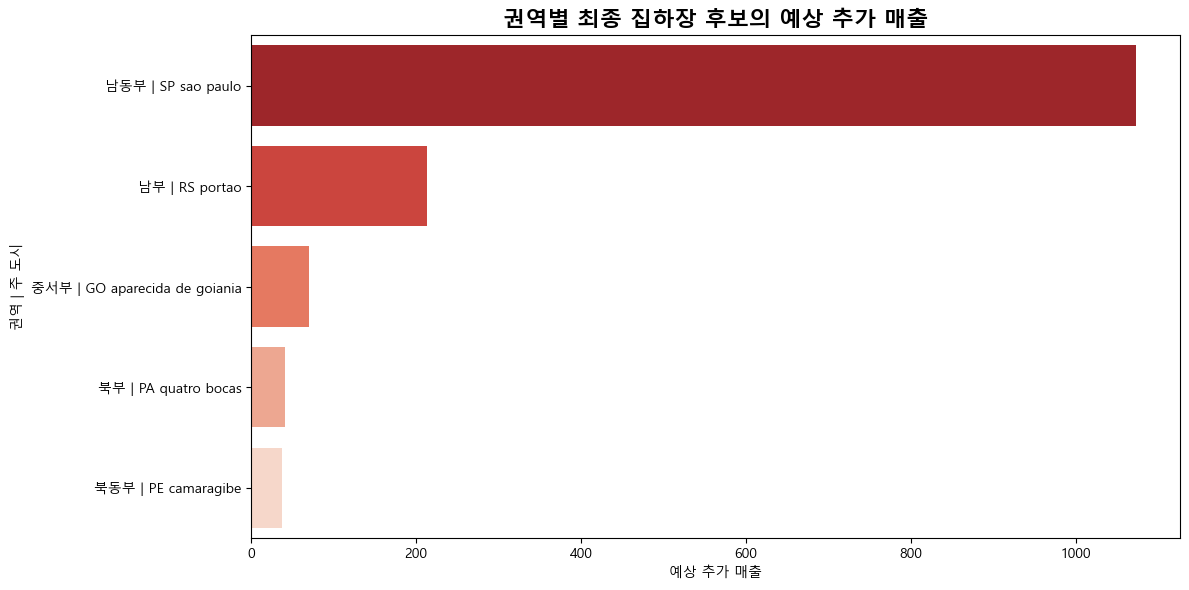

In [35]:
plot_hub = final_hub_by_region.copy()

plot_hub["label"] = (
    plot_hub["region"].astype(str)
    + " | "
    + plot_hub["state"].astype(str)
    + " "
    + plot_hub["suggested_city"].astype(str)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_hub.sort_values("expected_additional_revenue", ascending=False),
    y="label",
    x="expected_additional_revenue",
    palette="Reds_r"
)

plt.title("권역별 최종 집하장 후보의 예상 추가 매출", fontsize=16, weight="bold")
plt.xlabel("예상 추가 매출")
plt.ylabel("권역 | 주 도시")

plt.tight_layout()
plt.show()

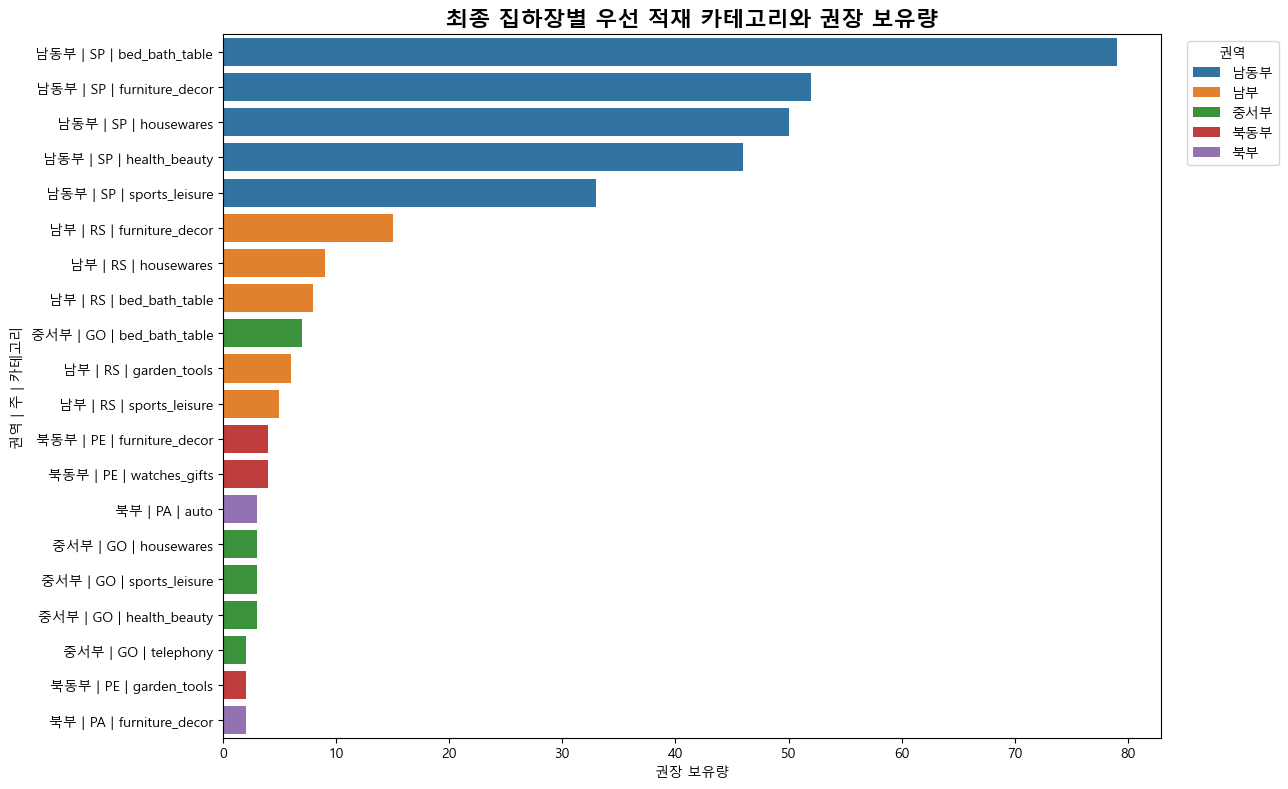

In [36]:
stock_plot = top_category_by_selected_state.copy()

stock_plot["label"] = (
    stock_plot["region"].astype(str)
    + " | "
    + stock_plot["customer_state"].astype(str)
    + " | "
    + stock_plot["category"].astype(str)
)

plt.figure(figsize=(13, 8))

sns.barplot(
    data=stock_plot.sort_values("recommended_stock", ascending=False),
    y="label",
    x="recommended_stock",
    hue="region",
    dodge=False
)

plt.title("최종 집하장별 우선 적재 카테고리와 권장 보유량", fontsize=16, weight="bold")
plt.xlabel("권장 보유량")
plt.ylabel("권역 | 주 | 카테고리")
plt.legend(title="권역", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 11. 최종 해석

본 분석은 Random Forest만 사용하던 기존 사전재고 수요 예측을 여러 scikit-learn 회귀 모델 비교 방식으로 확장하였다.

Random Forest, Extra Trees, Gradient Boosting, HistGradientBoosting을 동일한 학습/검증 데이터에서 비교하였고, RMSE가 가장 낮은 모델을 최종 수요 예측 모델로 선택하였다.

선택된 모델을 바탕으로 주-카테고리별 예상 판매량과 권장 보유량을 계산하였다. 이후 사전재고 운영이 가져올 수 있는 기대효과를 예상 주문 수, 예상 매출, 추가 주문 수, 추가 매출, 리뷰점수 개선, 지연 주문 감소 관점에서 산정하였다.

마지막으로 고객 수요 위치와 판매자 공급 위치를 기반으로 무가중 K-Means를 수행하여 주/도시 단위 집하장 후보를 생성하였다.

최종 집하장 후보는 단순 거리 중심이 아니라, 해당 주의 예상 판매량, 기대 매출, 커버 고객 주문 수, 배송 지연 감소 가능성을 함께 고려하여 선정하였다.

In [39]:
model_compare.to_csv(
    OUTPUT_DIR / "demand_model_comparison_without_xgboost.csv",
    index=False,
    encoding="utf-8-sig"
)

state_stock_plan.to_csv(
    OUTPUT_DIR / "state_category_stock_plan_with_best_sklearn_model.csv",
    index=False,
    encoding="utf-8-sig"
)

state_expected_effect.to_csv(
    OUTPUT_DIR / "state_inventory_expected_effect.csv",
    index=False,
    encoding="utf-8-sig"
)

region_hub_candidates.to_csv(
    OUTPUT_DIR / "region_hub_candidates_with_business_effect.csv",
    index=False,
    encoding="utf-8-sig"
)

final_hub_by_region.to_csv(
    OUTPUT_DIR / "final_hub_by_region_with_inventory_effect.csv",
    index=False,
    encoding="utf-8-sig"
)

top_category_by_selected_state.to_csv(
    OUTPUT_DIR / "final_hub_stock_category_plan.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료")
print(OUTPUT_DIR)

저장 완료
c:\Users\yiho1\포트폴리오 프로젝트\team-oldest-olist-analysis\notebooks\Distribution_hub\HY\Logistics_folder\outputs


---

# 저장 결과 기반 기대효과 종합 시각화

## 분석 목적

본 단계에서는 앞서 저장한 CSV 결과를 다시 불러와, 사전재고 및 집하장 운영의 기대효과를 종합적으로 확인한다.

기대효과는 다음 지표를 중심으로 해석한다.

1. 예상 판매량
2. 권장 보유량
3. 예상 매출
4. 예상 추가 주문 수
5. 예상 추가 매출
6. 예상 배송 지연 감소 주문 수
7. 예상 리뷰점수 개선

이를 통해 단순히 집하장 후보를 제안하는 것에서 나아가, 해당 전략이 어떤 비즈니스 효과를 기대할 수 있는지 정량적으로 제시한다.

In [44]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

ROOT = Path.cwd()

while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

OUTPUT_DIR = (
    ROOT
    / "notebooks"
    / "Distribution_hub"
    / "HY"
    / "Logistics_folder"
    / "outputs"
)

print("불러올 경로:", OUTPUT_DIR)

불러올 경로: c:\Users\yiho1\포트폴리오 프로젝트\team-oldest-olist-analysis\notebooks\Distribution_hub\HY\Logistics_folder\outputs


In [45]:
model_compare_viz = pd.read_csv(
    OUTPUT_DIR / "demand_model_comparison_without_xgboost.csv"
)

state_stock_plan_viz = pd.read_csv(
    OUTPUT_DIR / "state_category_stock_plan_with_best_sklearn_model.csv"
)

state_expected_effect_viz = pd.read_csv(
    OUTPUT_DIR / "state_inventory_expected_effect.csv"
)

region_hub_candidates_viz = pd.read_csv(
    OUTPUT_DIR / "region_hub_candidates_with_business_effect.csv"
)

final_hub_by_region_viz = pd.read_csv(
    OUTPUT_DIR / "final_hub_by_region_with_inventory_effect.csv"
)

top_category_by_selected_state_viz = pd.read_csv(
    OUTPUT_DIR / "final_hub_stock_category_plan.csv"
)

print("model_compare:", model_compare_viz.shape)
print("state_stock_plan:", state_stock_plan_viz.shape)
print("state_expected_effect:", state_expected_effect_viz.shape)
print("region_hub_candidates:", region_hub_candidates_viz.shape)
print("final_hub_by_region:", final_hub_by_region_viz.shape)
print("top_category_by_selected_state:", top_category_by_selected_state_viz.shape)

model_compare: (4, 4)
state_stock_plan: (108, 21)
state_expected_effect: (48, 21)
region_hub_candidates: (55, 24)
final_hub_by_region: (5, 24)
top_category_by_selected_state: (20, 24)


## 2. 수요예측 모델 성능 비교

사전재고 수요예측에는 여러 scikit-learn 회귀 모델을 비교하였다.

RMSE가 낮을수록 예측 오차가 작고, R²가 높을수록 월별 주문 수 변동을 더 잘 설명한다.

,model,MAE,RMSE,R2
0,GradientBoosting,1.3862,2.6944,0.8413
1,RandomForest,1.5311,3.0109,0.8018
2,HistGradientBoosting,1.4721,3.0153,0.8013
3,ExtraTrees,1.6959,3.1292,0.7860


C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\805589313.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\805589313.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\805589313.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


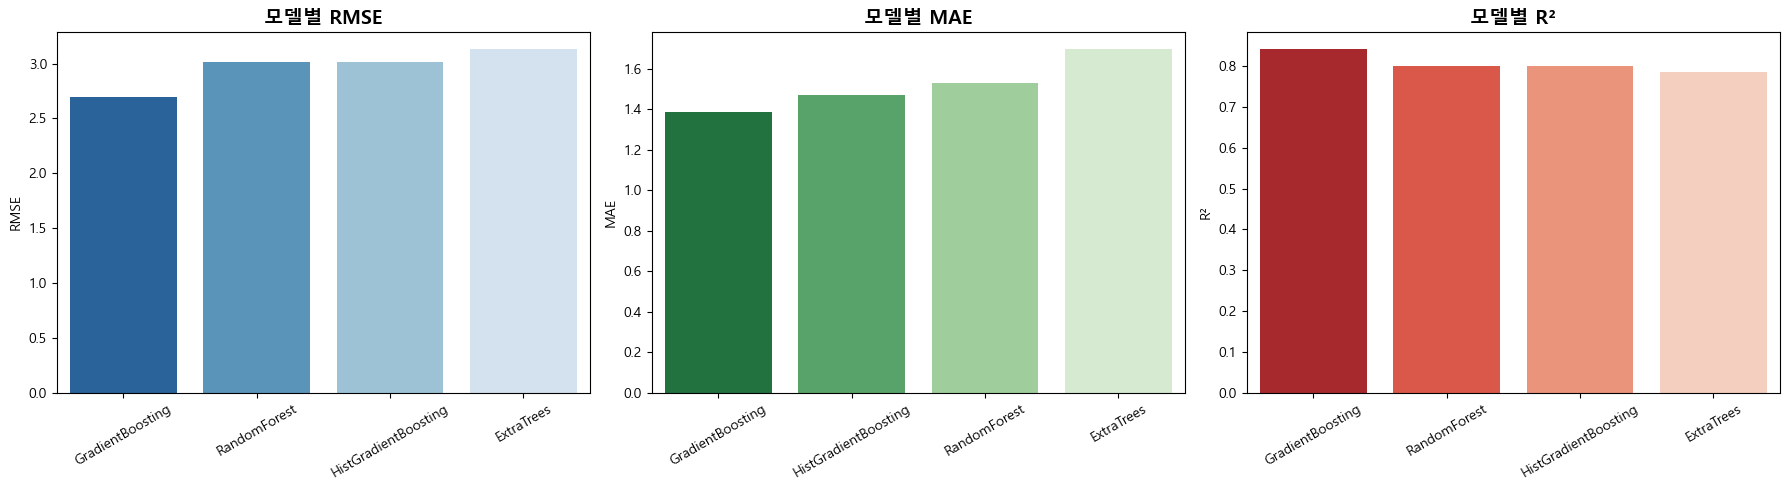

In [46]:
display(model_compare_viz)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=model_compare_viz.sort_values("RMSE"),
    x="model",
    y="RMSE",
    ax=axes[0],
    palette="Blues_r"
)
axes[0].set_title("모델별 RMSE", fontsize=14, weight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=model_compare_viz.sort_values("MAE"),
    x="model",
    y="MAE",
    ax=axes[1],
    palette="Greens_r"
)
axes[1].set_title("모델별 MAE", fontsize=14, weight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(
    data=model_compare_viz.sort_values("R2", ascending=False),
    x="model",
    y="R2",
    ax=axes[2],
    palette="Reds_r"
)
axes[2].set_title("모델별 R²", fontsize=14, weight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 3. 권역별 주-카테고리 예상 판매량과 권장 보유량

전체 Top 20만 확인하면 주문 규모가 큰 남동부와 남부 지역이 대부분을 차지할 수 있다.

따라서 권역별로 각각 예상 판매량이 높은 주-카테고리 조합을 확인한다.

이 방식은 각 권역 내부에서 어떤 주와 카테고리가 사전재고 우선 후보인지 비교하는 데 적합하다.

In [49]:
top_n_per_region = 5

region_state_category_sales = (
    state_stock_plan_viz
    .sort_values(
        ["customer_region", "predicted_monthly_order"],
        ascending=[True, False]
    )
    .groupby("customer_region", as_index=False)
    .head(top_n_per_region)
    .copy()
)

region_state_category_sales["label"] = (
    region_state_category_sales["customer_state"].astype(str)
    + " | "
    + region_state_category_sales["category"].astype(str)
)

display(region_state_category_sales[[
    "customer_region",
    "customer_state",
    "category",
    "predicted_monthly_order",
    "recommended_stock",
    "expected_revenue",
    "delay_rate",
    "avg_delivery_days",
    "avg_review_score"
]])

,customer_region,customer_state,category,predicted_monthly_order,recommended_stock,expected_revenue,delay_rate,avg_delivery_days,avg_review_score
0,남동부,SP,bed_bath_table,46.8701,79.0000,"10,818.7385",0.1481,6.3611,3.8981
1,남동부,SP,housewares,32.4312,50.0000,"4,029.1640",0.1111,4.5139,3.9571
2,남동부,SP,furniture_decor,30.1043,52.0000,"8,246.1364",0.1250,5.3500,3.5500
3,남동부,SP,health_beauty,23.7512,46.0000,"7,674.4724",0.1618,4.5882,4.0909
4,남동부,SP,sports_leisure,21.4555,33.0000,"2,805.5982",0.0000,4.0682,3.7955
9,남부,RS,furniture_decor,9.7110,15.0000,"2,775.2861",0.0526,10.4211,3.5263
19,남부,RS,housewares,6.0639,9.0000,"1,156.4215",0.1818,6.3636,4.3636
23,남부,PR,furniture_decor,5.0584,11.0000,"1,122.9299",0.0000,6.8571,3.4286
26,남부,RS,bed_bath_table,4.5723,8.0000,"1,349.7276",0.0000,10.1250,4.5000
27,남부,PR,computers_accessories,4.4122,8.0000,"1,434.1432",0.2222,12.8889,4.5556


C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\2244756955.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


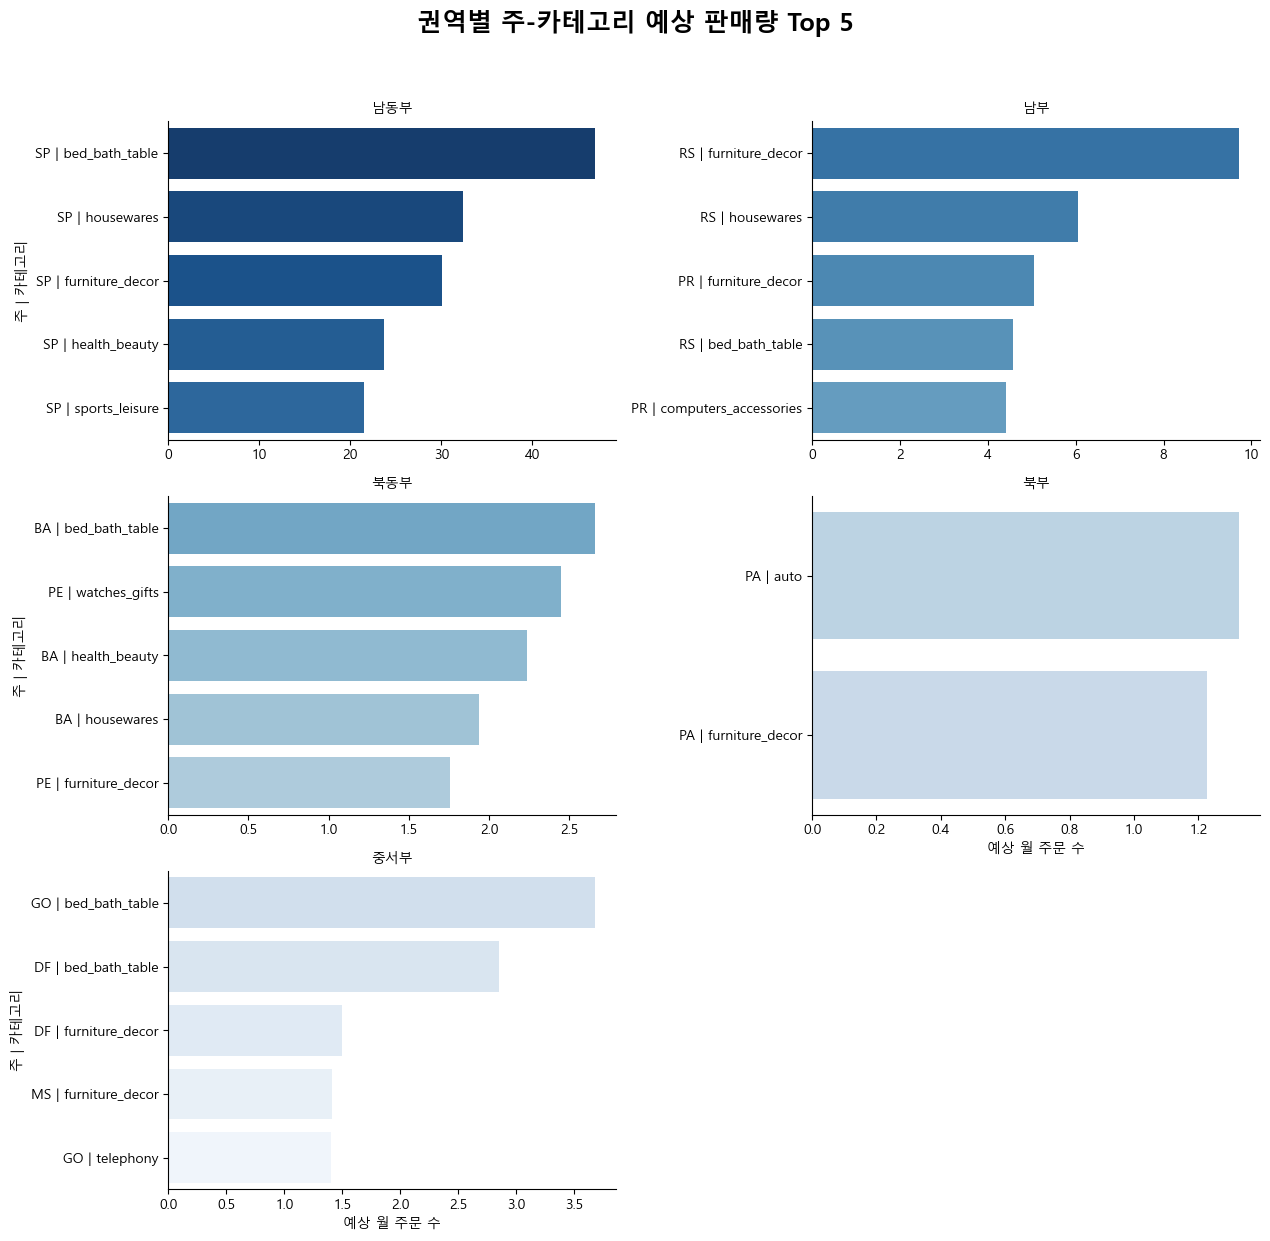

In [50]:
g = sns.catplot(
    data=region_state_category_sales,
    kind="bar",
    col="customer_region",
    col_wrap=2,
    y="label",
    x="predicted_monthly_order",
    sharex=False,
    sharey=False,
    height=4,
    aspect=1.6,
    palette="Blues_r"
)

g.set_titles("{col_name}")
g.set_axis_labels("예상 월 주문 수", "주 | 카테고리")
g.fig.suptitle("권역별 주-카테고리 예상 판매량 Top 5", fontsize=18, weight="bold", y=1.03)

plt.tight_layout()
plt.show()

## 권역별 주-카테고리 권장 보유량

권장 보유량은 예상 판매량에 월별 수요 변동성을 반영한 값이다.

따라서 예상 판매량이 비슷하더라도 수요 변동성이 큰 카테고리는 더 많은 안전재고가 필요할 수 있다.

In [51]:
region_state_category_stock = (
    state_stock_plan_viz
    .sort_values(
        ["customer_region", "recommended_stock"],
        ascending=[True, False]
    )
    .groupby("customer_region", as_index=False)
    .head(top_n_per_region)
    .copy()
)

region_state_category_stock["label"] = (
    region_state_category_stock["customer_state"].astype(str)
    + " | "
    + region_state_category_stock["category"].astype(str)
)

display(region_state_category_stock[[
    "customer_region",
    "customer_state",
    "category",
    "predicted_monthly_order",
    "recommended_stock",
    "expected_revenue",
    "delay_rate",
    "avg_delivery_days",
    "avg_review_score"
]])

,customer_region,customer_state,category,predicted_monthly_order,recommended_stock,expected_revenue,delay_rate,avg_delivery_days,avg_review_score
0,남동부,SP,bed_bath_table,46.8701,79.0000,"10,818.7385",0.1481,6.3611,3.8981
2,남동부,SP,furniture_decor,30.1043,52.0000,"8,246.1364",0.1250,5.3500,3.5500
1,남동부,SP,housewares,32.4312,50.0000,"4,029.1640",0.1111,4.5139,3.9571
3,남동부,SP,health_beauty,23.7512,46.0000,"7,674.4724",0.1618,4.5882,4.0909
5,남동부,SP,computers_accessories,13.0412,35.0000,"4,085.3591",0.1935,8.7097,3.8065
9,남부,RS,furniture_decor,9.7110,15.0000,"2,775.2861",0.0526,10.4211,3.5263
23,남부,PR,furniture_decor,5.0584,11.0000,"1,122.9299",0.0000,6.8571,3.4286
19,남부,RS,housewares,6.0639,9.0000,"1,156.4215",0.1818,6.3636,4.3636
26,남부,RS,bed_bath_table,4.5723,8.0000,"1,349.7276",0.0000,10.1250,4.5000
27,남부,PR,computers_accessories,4.4122,8.0000,"1,434.1432",0.2222,12.8889,4.5556


C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\291661417.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


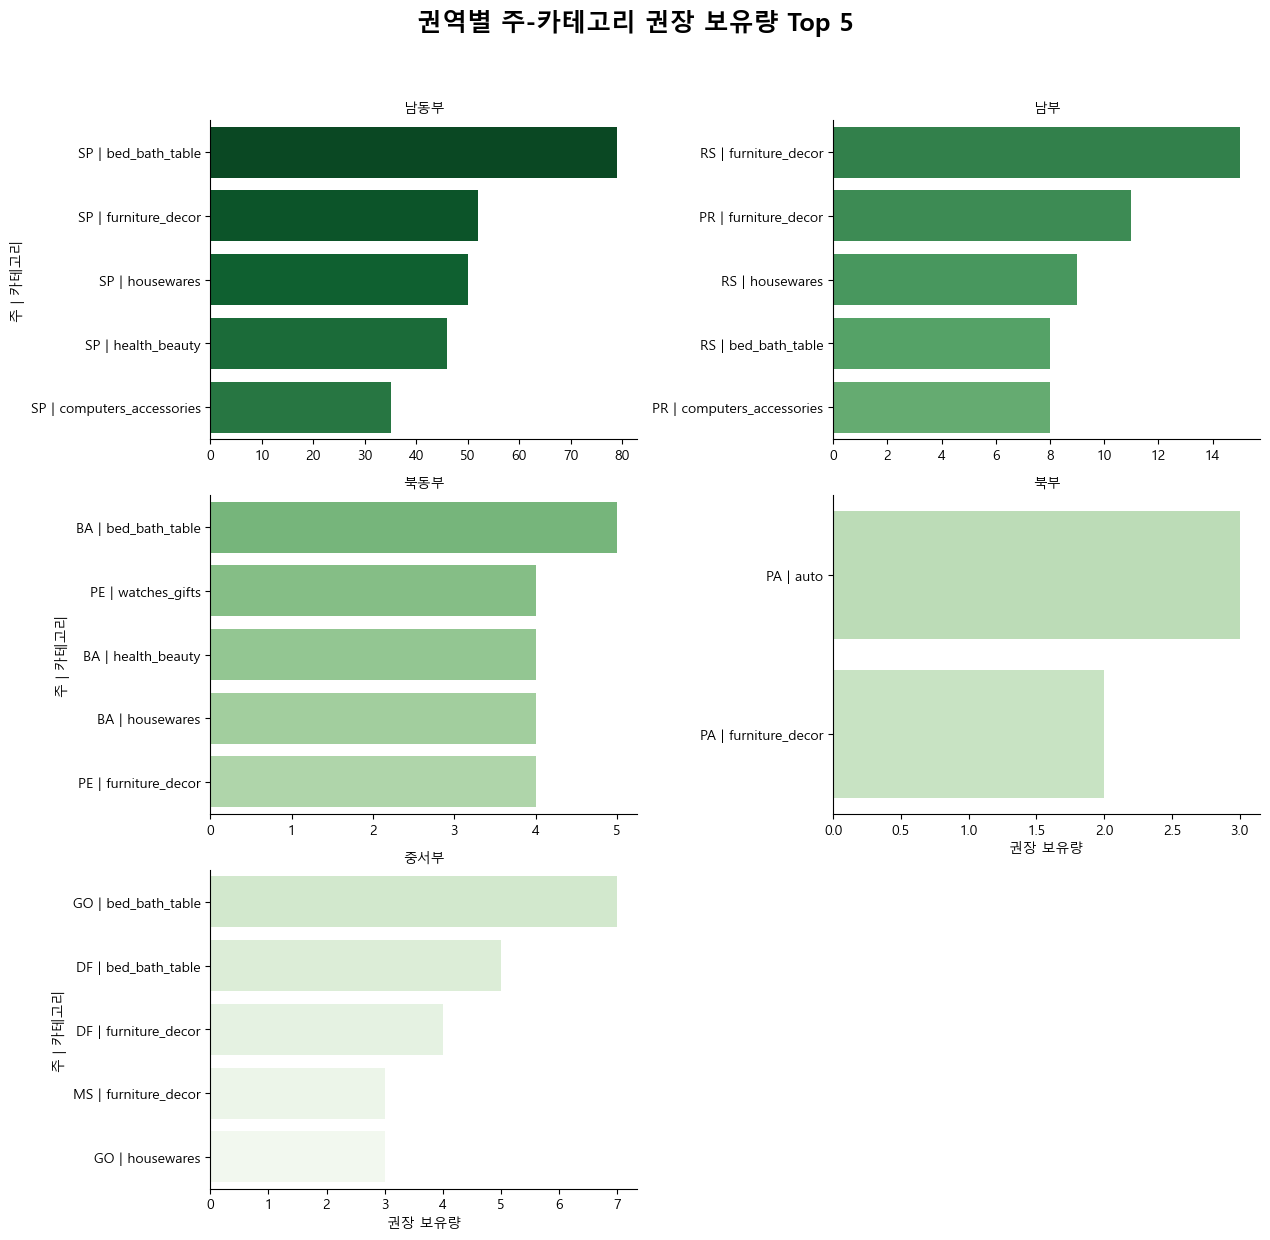

In [52]:
g = sns.catplot(
    data=region_state_category_stock,
    kind="bar",
    col="customer_region",
    col_wrap=2,
    y="label",
    x="recommended_stock",
    sharex=False,
    sharey=False,
    height=4,
    aspect=1.6,
    palette="Greens_r"
)

g.set_titles("{col_name}")
g.set_axis_labels("권장 보유량", "주 | 카테고리")
g.fig.suptitle("권역별 주-카테고리 권장 보유량 Top 5", fontsize=18, weight="bold", y=1.03)

plt.tight_layout()
plt.show()

## 4. 시나리오별 전체 기대효과

사전재고와 집하장 운영의 기대효과를 보수적, 기준, 낙관적 시나리오로 비교한다.

각 시나리오는 지연 감소율, 리뷰점수 개선폭, 주문 증가율을 다르게 가정한다.

In [53]:
effect_df = state_expected_effect_viz.copy()

effect_summary = (
    effect_df
    .groupby("scenario", as_index=False)
    .agg(
        total_predicted_orders=("predicted_order_sum", "sum"),
        total_recommended_stock=("recommended_stock_sum", "sum"),
        total_expected_revenue=("expected_revenue_sum", "sum"),
        total_additional_orders=("expected_additional_orders", "sum"),
        total_additional_revenue=("expected_additional_revenue", "sum"),
        total_prevented_delay_orders=("expected_prevented_delay_orders", "sum"),
        avg_review_before=("avg_review_score", "mean"),
        avg_review_after=("expected_review_score_after_effect", "mean")
    )
)

effect_summary["review_score_uplift"] = (
    effect_summary["avg_review_after"]
    - effect_summary["avg_review_before"]
)

display(effect_summary)

,scenario,total_predicted_orders,total_recommended_stock,total_expected_revenue,total_additional_orders,total_additional_revenue,total_prevented_delay_orders,avg_review_before,avg_review_after,review_score_uplift
0,기준,463.2341,897.0000,"111,775.6603",9.2647,"2,310.6568",8.1529,3.4042,3.4605,0.0562
1,낙관적,463.2341,897.0000,"111,775.6603",13.8970,"3,465.9852",12.2294,3.4042,3.4980,0.0938
2,보수적,463.2341,897.0000,"111,775.6603",4.6323,"1,155.3284",4.0765,3.4042,3.4324,0.0281


C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\2121455257.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\2121455257.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\2121455257.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\2121455257.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hu

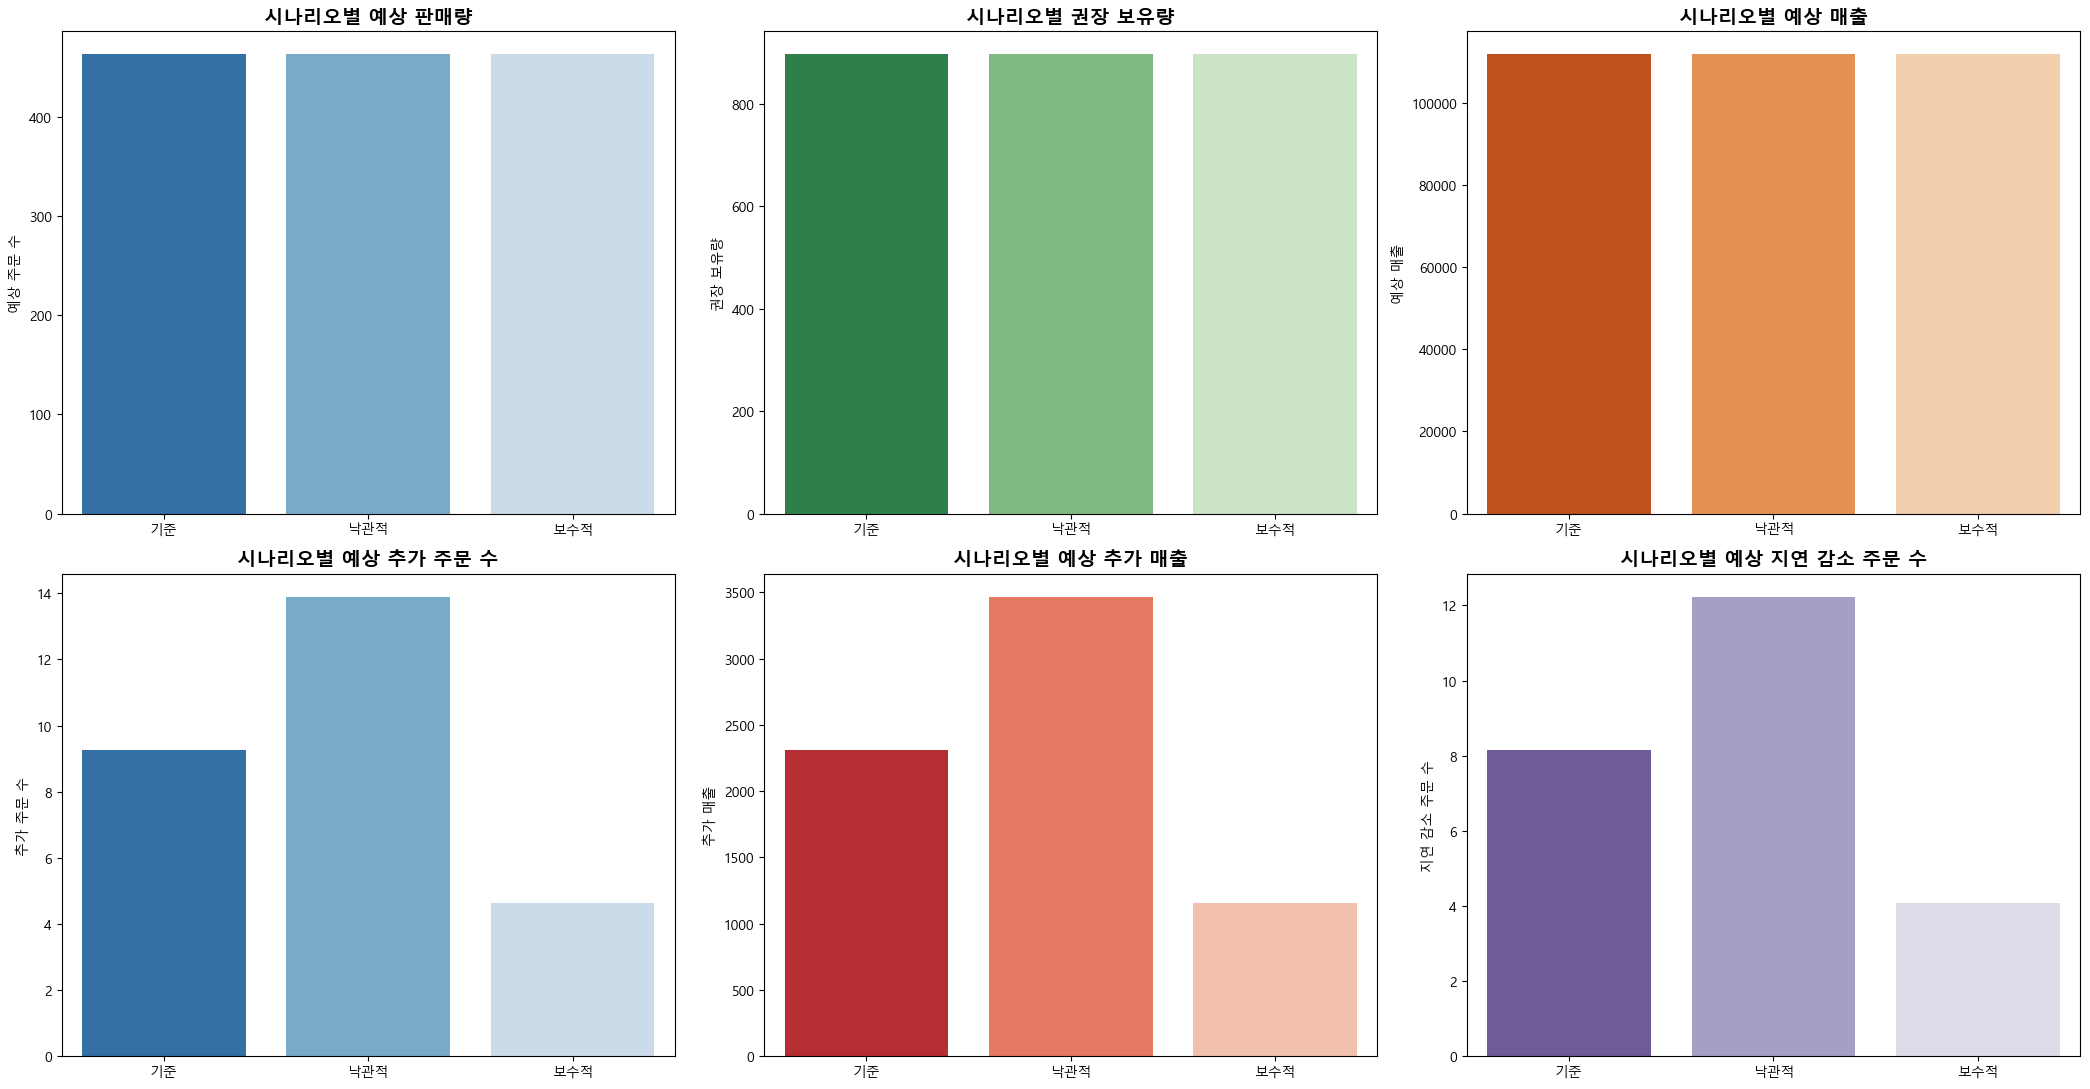

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(21, 11))

sns.barplot(
    data=effect_summary,
    x="scenario",
    y="total_predicted_orders",
    ax=axes[0, 0],
    palette="Blues_r"
)
axes[0, 0].set_title("시나리오별 예상 판매량", fontsize=14, weight="bold")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("예상 주문 수")

sns.barplot(
    data=effect_summary,
    x="scenario",
    y="total_recommended_stock",
    ax=axes[0, 1],
    palette="Greens_r"
)
axes[0, 1].set_title("시나리오별 권장 보유량", fontsize=14, weight="bold")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("권장 보유량")

sns.barplot(
    data=effect_summary,
    x="scenario",
    y="total_expected_revenue",
    ax=axes[0, 2],
    palette="Oranges_r"
)
axes[0, 2].set_title("시나리오별 예상 매출", fontsize=14, weight="bold")
axes[0, 2].set_xlabel("")
axes[0, 2].set_ylabel("예상 매출")

sns.barplot(
    data=effect_summary,
    x="scenario",
    y="total_additional_orders",
    ax=axes[1, 0],
    palette="Blues_r"
)
axes[1, 0].set_title("시나리오별 예상 추가 주문 수", fontsize=14, weight="bold")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("추가 주문 수")

sns.barplot(
    data=effect_summary,
    x="scenario",
    y="total_additional_revenue",
    ax=axes[1, 1],
    palette="Reds_r"
)
axes[1, 1].set_title("시나리오별 예상 추가 매출", fontsize=14, weight="bold")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("추가 매출")

sns.barplot(
    data=effect_summary,
    x="scenario",
    y="total_prevented_delay_orders",
    ax=axes[1, 2],
    palette="Purples_r"
)
axes[1, 2].set_title("시나리오별 예상 지연 감소 주문 수", fontsize=14, weight="bold")
axes[1, 2].set_xlabel("")
axes[1, 2].set_ylabel("지연 감소 주문 수")

plt.tight_layout()
plt.show()

## 5. 리뷰점수 개선 효과

리뷰점수 개선 효과는 배송 지연 감소가 고객 만족도 개선으로 이어진다는 가정에 기반한다.

이는 실제 결과를 확정하는 값이 아니라, 배송 경험 개선의 방향성과 규모를 보여주는 시뮬레이션이다.

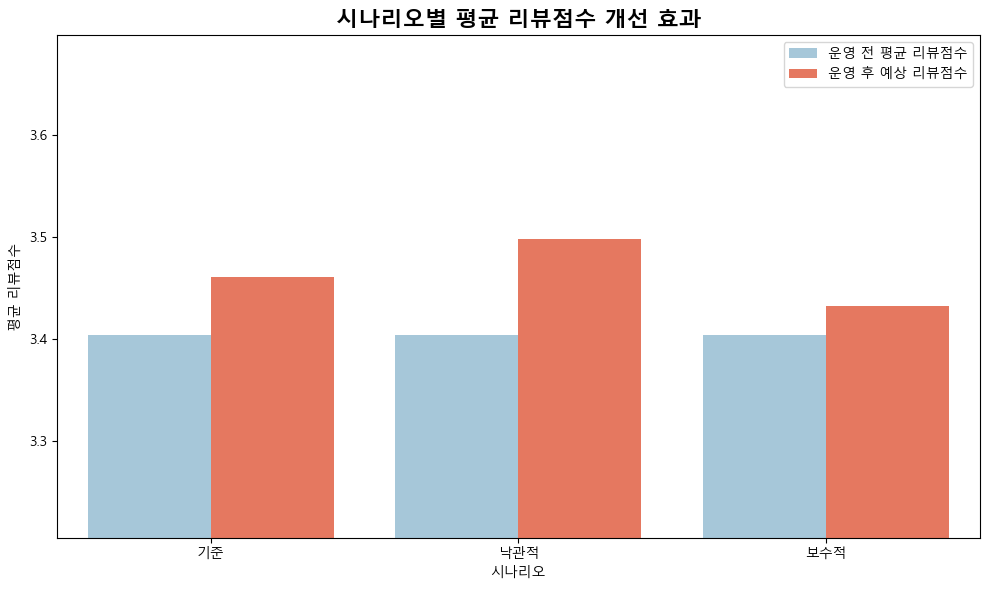

In [55]:
review_plot_long = effect_summary.melt(
    id_vars="scenario",
    value_vars=["avg_review_before", "avg_review_after"],
    var_name="review_type",
    value_name="review_score"
)

review_type_map = {
    "avg_review_before": "운영 전 평균 리뷰점수",
    "avg_review_after": "운영 후 예상 리뷰점수"
}

review_plot_long["review_type"] = review_plot_long["review_type"].map(review_type_map)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=review_plot_long,
    x="scenario",
    y="review_score",
    hue="review_type",
    palette=["#9ecae1", "#fb6a4a"]
)

plt.title("시나리오별 평균 리뷰점수 개선 효과", fontsize=16, weight="bold")
plt.xlabel("시나리오")
plt.ylabel("평균 리뷰점수")
plt.ylim(
    max(0, review_plot_long["review_score"].min() - 0.2),
    min(5, review_plot_long["review_score"].max() + 0.2)
)
plt.legend(title="")
plt.tight_layout()
plt.show()

## 6. 기준 시나리오 기준 주별 기대효과

기준 시나리오를 중심으로 주별 기대효과를 비교한다.

이 표에서는 예상 판매량, 권장 보유량, 예상 매출, 추가 주문 수, 추가 매출, 지연 감소 주문 수, 리뷰점수 개선 효과를 함께 확인한다.

In [56]:
baseline_effect_detail = effect_df[
    effect_df["scenario"].eq("기준")
].copy()

baseline_effect_detail = baseline_effect_detail.sort_values(
    "predicted_order_sum",
    ascending=False
)

display(baseline_effect_detail[[
    "customer_region",
    "customer_state",
    "predicted_order_sum",
    "recommended_stock_sum",
    "expected_revenue_sum",
    "expected_additional_orders",
    "expected_additional_revenue",
    "expected_prevented_delay_orders",
    "avg_review_score",
    "expected_review_score_after_effect"
]].head(20))

,customer_region,customer_state,predicted_order_sum,recommended_stock_sum,expected_revenue_sum,expected_additional_orders,expected_additional_revenue,expected_prevented_delay_orders,avg_review_score,expected_review_score_after_effect
19,남동부,SP,236.1997,418.0000,"52,557.6879",4.7240,"1,072.4707",6.3603,3.8231,3.8831
18,남동부,RJ,55.4635,112.0000,"11,115.8401",1.1093,235.7411,0.2613,3.1768,3.2368
17,남동부,MG,41.9139,103.0000,"12,521.6702",0.8383,277.3325,0.3224,3.7903,3.8503
21,남부,RS,33.3283,65.0000,"9,940.8556",0.6666,212.9908,0.1302,4.2131,4.2731
20,남부,PR,27.9211,61.0000,"5,689.1086",0.5584,99.9121,0.0955,4.0372,4.0972
22,남부,SC,19.8391,42.0000,"4,171.8150",0.3968,82.1452,0.3968,4.1131,4.1731
28,중서부,DF,9.6483,21.0000,"3,369.1659",0.1930,65.9023,0.0000,3.2143,3.2743
29,중서부,GO,8.6974,18.0000,"3,096.9157",0.1739,69.8479,0.2087,4.5000,4.5600
23,북동부,BA,8.2205,17.0000,"1,213.3443",0.1644,25.0677,0.0000,3.9583,4.0183
26,북동부,PE,5.4132,10.0000,"1,713.6656",0.1083,37.6715,0.1444,2.2667,2.3267


C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\1344206046.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\1344206046.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\1344206046.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


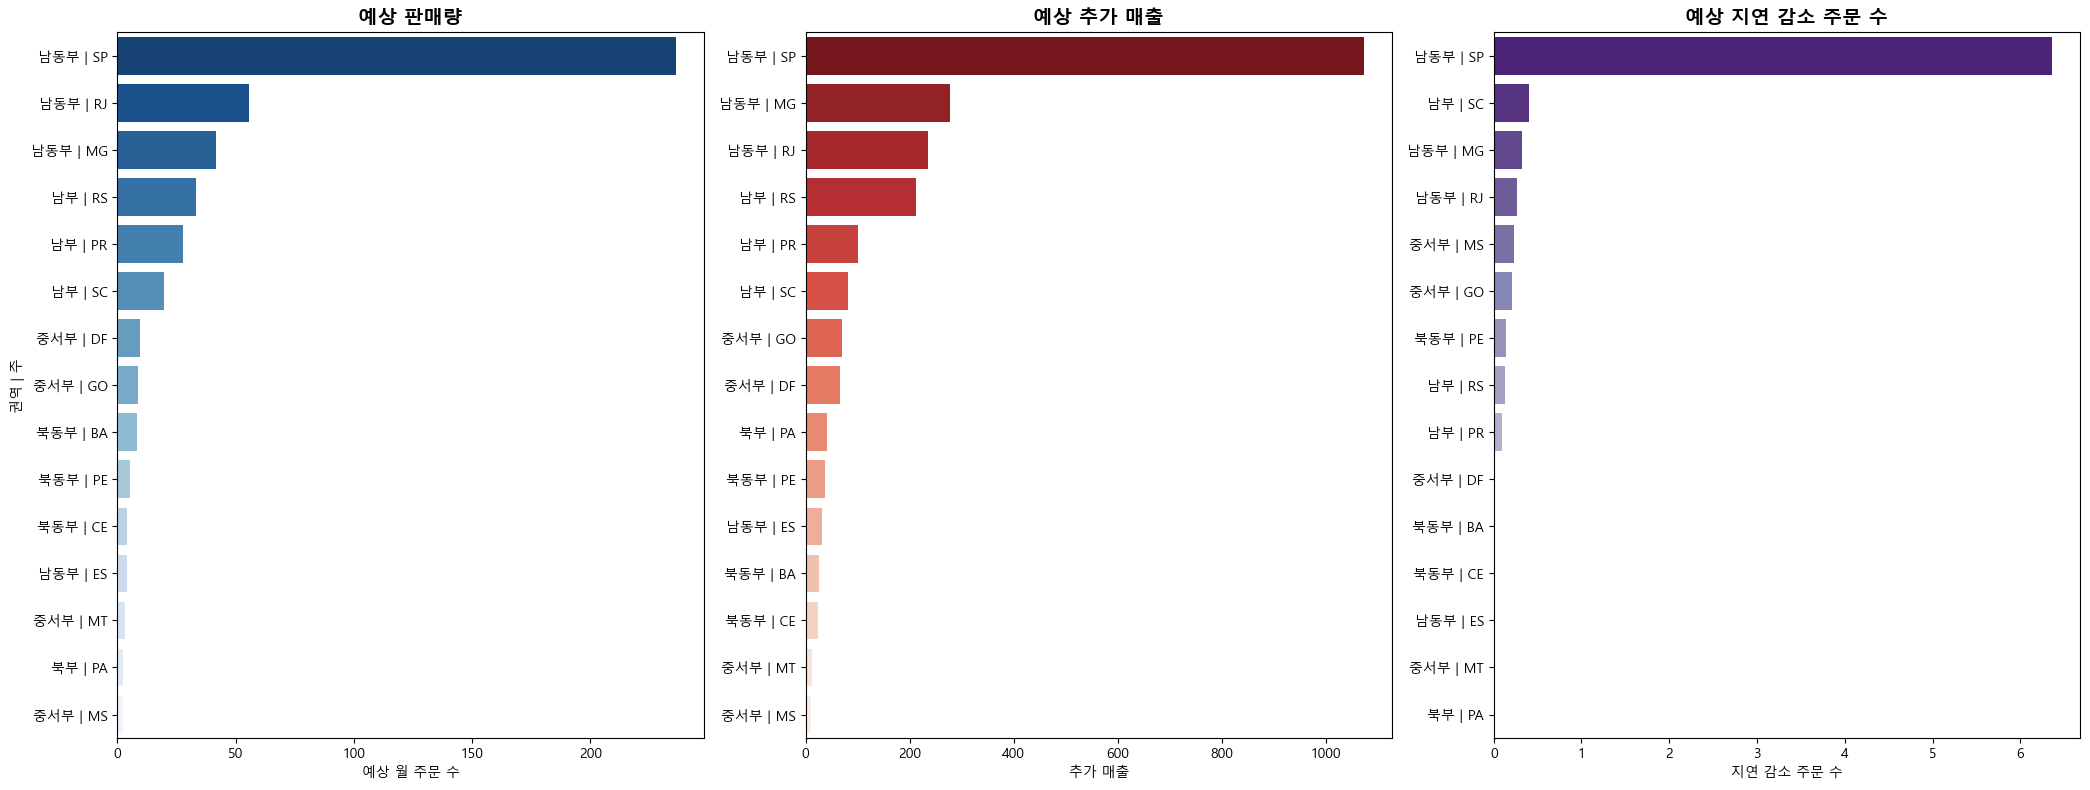

In [57]:
baseline_top = baseline_effect_detail.head(15).copy()

baseline_top["label"] = (
    baseline_top["customer_region"].astype(str)
    + " | "
    + baseline_top["customer_state"].astype(str)
)

fig, axes = plt.subplots(1, 3, figsize=(21, 8))

sns.barplot(
    data=baseline_top,
    y="label",
    x="predicted_order_sum",
    ax=axes[0],
    palette="Blues_r"
)
axes[0].set_title("예상 판매량", fontsize=14, weight="bold")
axes[0].set_xlabel("예상 월 주문 수")
axes[0].set_ylabel("권역 | 주")

sns.barplot(
    data=baseline_top.sort_values("expected_additional_revenue", ascending=False),
    y="label",
    x="expected_additional_revenue",
    ax=axes[1],
    palette="Reds_r"
)
axes[1].set_title("예상 추가 매출", fontsize=14, weight="bold")
axes[1].set_xlabel("추가 매출")
axes[1].set_ylabel("")

sns.barplot(
    data=baseline_top.sort_values("expected_prevented_delay_orders", ascending=False),
    y="label",
    x="expected_prevented_delay_orders",
    ax=axes[2],
    palette="Purples_r"
)
axes[2].set_title("예상 지연 감소 주문 수", fontsize=14, weight="bold")
axes[2].set_xlabel("지연 감소 주문 수")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

## 7. 기대효과 포트폴리오 맵

예상 판매량, 예상 추가 매출, 지연 감소 효과를 동시에 비교한다.

- x축: 예상 추가 매출
- y축: 예상 지연 감소 주문 수
- 점 크기: 예상 판매량
- 색상: 고객 권역

오른쪽 위에 위치하면서 점 크기가 큰 주는 사업적 효과와 배송 개선 효과가 동시에 큰 지역으로 해석할 수 있다.

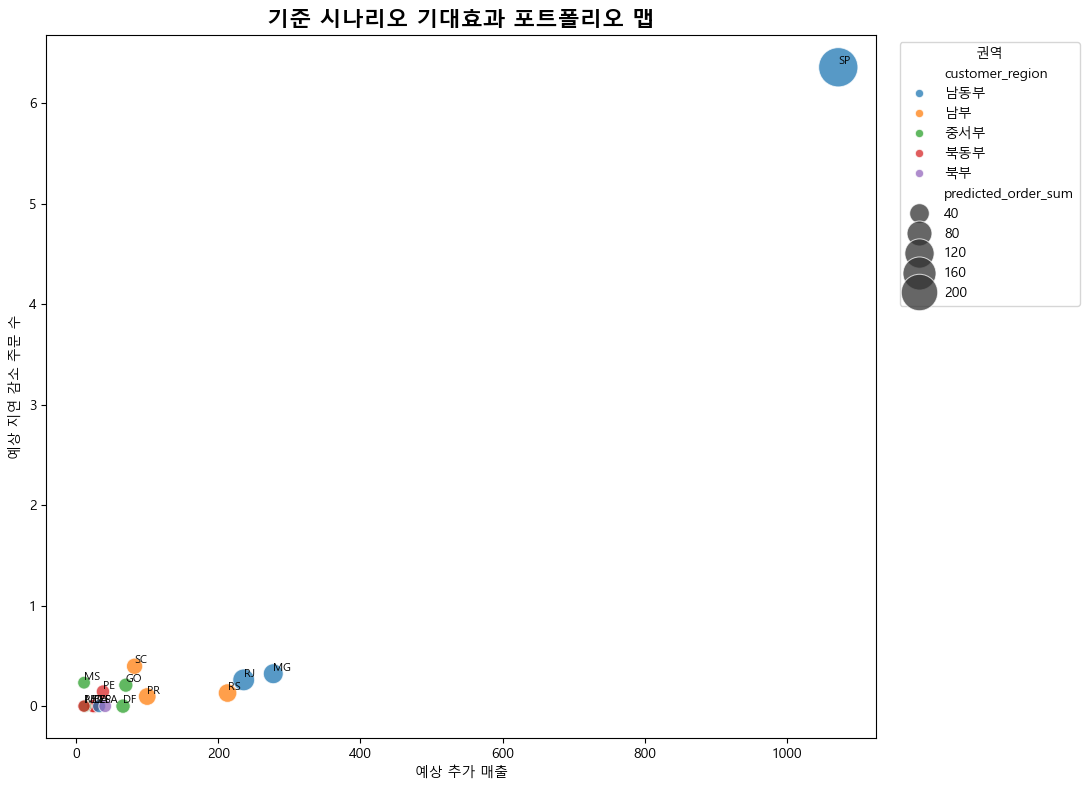

In [58]:
plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=baseline_effect_detail,
    x="expected_additional_revenue",
    y="expected_prevented_delay_orders",
    size="predicted_order_sum",
    hue="customer_region",
    sizes=(80, 800),
    alpha=0.75
)

for _, row in baseline_effect_detail.iterrows():
    plt.text(
        row["expected_additional_revenue"],
        row["expected_prevented_delay_orders"],
        row["customer_state"],
        fontsize=8,
        ha="left",
        va="bottom"
    )

plt.title("기준 시나리오 기대효과 포트폴리오 맵", fontsize=16, weight="bold")
plt.xlabel("예상 추가 매출")
plt.ylabel("예상 지연 감소 주문 수")
plt.legend(title="권역", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8. 권역별 최종 집하장 후보와 기대효과

권역별 최종 집하장 후보가 어느 정도의 예상 판매량, 추가 매출, 지연 감소 효과를 가지는지 확인한다.

In [59]:
display(final_hub_by_region_viz[[
    "region",
    "state",
    "suggested_city",
    "suggested_zip_code_prefix",
    "predicted_order_sum",
    "recommended_stock_sum",
    "expected_revenue_sum",
    "expected_additional_revenue",
    "expected_prevented_delay_orders",
    "covered_customer_orders",
    "covered_seller_orders",
    "avg_delivery_days",
    "late_rate",
    "avg_review_score",
    "avg_distance_to_hub_km"
]])

,region,state,suggested_city,suggested_zip_code_prefix,predicted_order_sum,recommended_stock_sum,expected_revenue_sum,expected_additional_revenue,expected_prevented_delay_orders,covered_customer_orders,covered_seller_orders,avg_delivery_days,late_rate,avg_review_score,avg_distance_to_hub_km
0,남동부,SP,sao paulo,2013,236.1997,418.0000,"52,557.6879","1,072.4707",6.3603,32748,47319,7.9376,0.0632,4.2307,29.7173
1,남부,RS,portao,93180,33.3283,65.0000,"9,940.8556",212.9908,0.1302,3543,1754,15.1172,0.0802,4.1335,54.7989
2,북동부,PE,camaragibe,54767,5.4132,10.0000,"1,713.6656",37.6715,0.1444,1129,355,18.7768,0.1246,4.0000,23.1827
3,북부,PA,quatro bocas,68682,2.5537,5.0000,"1,988.6452",40.8263,0.0000,932,0,24.4072,0.1398,3.8318,274.1671
4,중서부,GO,aparecida de goiania,74921,8.6974,18.0000,"3,096.9157",69.8479,0.2087,1281,395,15.5207,0.1012,4.0739,48.2254


C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\3963288197.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\3963288197.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\3963288197.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


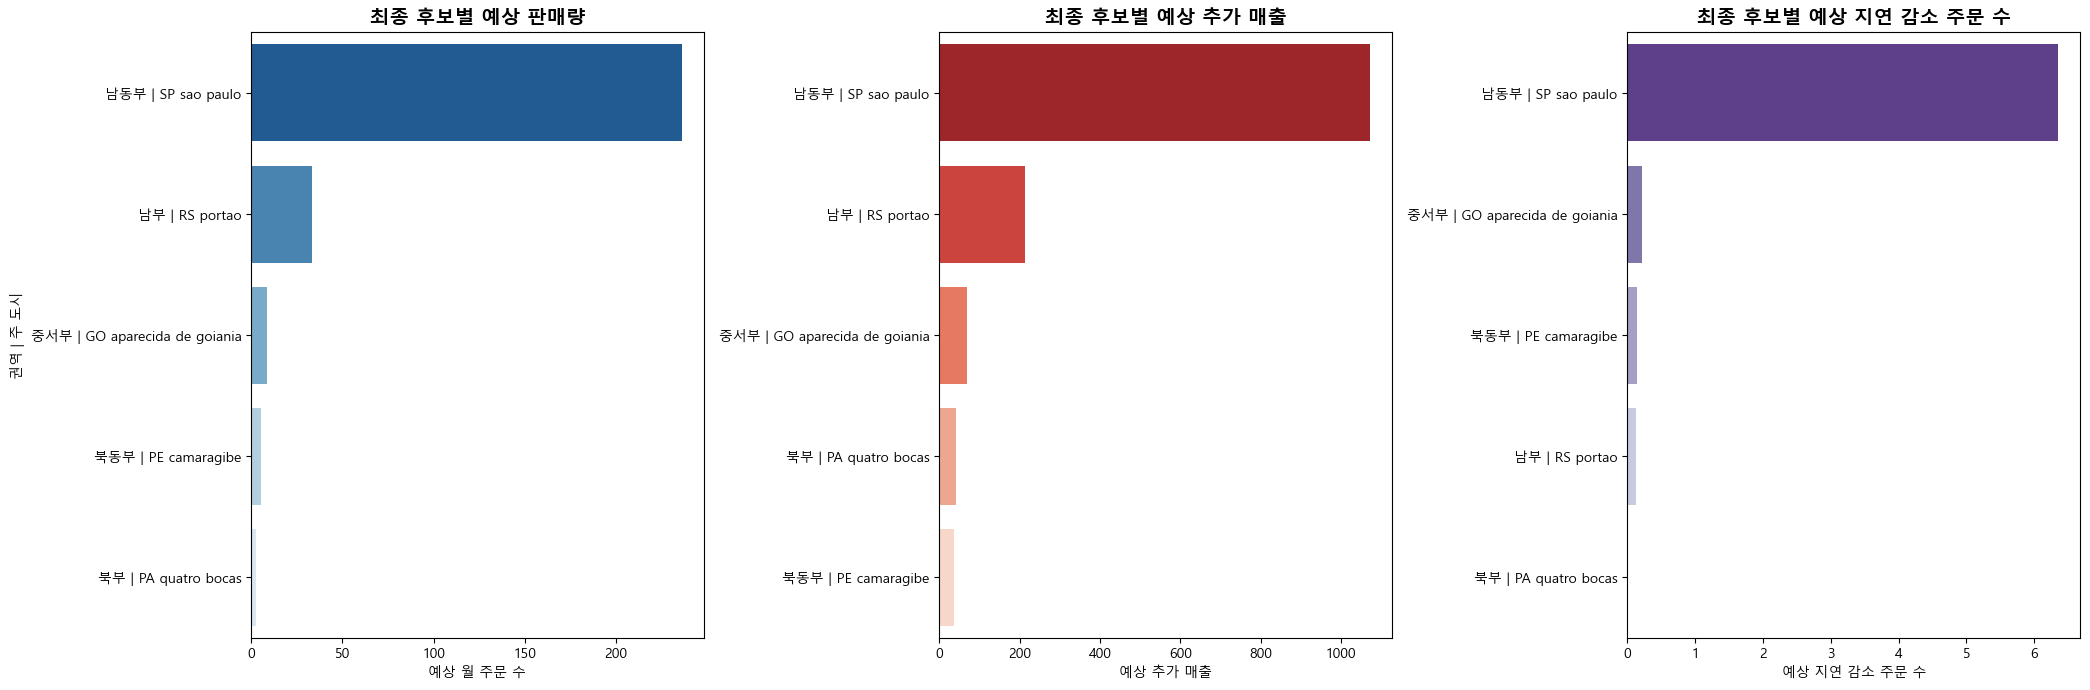

In [60]:
final_hub_plot = final_hub_by_region_viz.copy()

final_hub_plot["label"] = (
    final_hub_plot["region"].astype(str)
    + " | "
    + final_hub_plot["state"].astype(str)
    + " "
    + final_hub_plot["suggested_city"].astype(str)
)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

sns.barplot(
    data=final_hub_plot.sort_values("predicted_order_sum", ascending=False),
    y="label",
    x="predicted_order_sum",
    ax=axes[0],
    palette="Blues_r"
)
axes[0].set_title("최종 후보별 예상 판매량", fontsize=14, weight="bold")
axes[0].set_xlabel("예상 월 주문 수")
axes[0].set_ylabel("권역 | 주 도시")

sns.barplot(
    data=final_hub_plot.sort_values("expected_additional_revenue", ascending=False),
    y="label",
    x="expected_additional_revenue",
    ax=axes[1],
    palette="Reds_r"
)
axes[1].set_title("최종 후보별 예상 추가 매출", fontsize=14, weight="bold")
axes[1].set_xlabel("예상 추가 매출")
axes[1].set_ylabel("")

sns.barplot(
    data=final_hub_plot.sort_values("expected_prevented_delay_orders", ascending=False),
    y="label",
    x="expected_prevented_delay_orders",
    ax=axes[2],
    palette="Purples_r"
)
axes[2].set_title("최종 후보별 예상 지연 감소 주문 수", fontsize=14, weight="bold")
axes[2].set_xlabel("예상 지연 감소 주문 수")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

## 남동부 제외 최종 후보 기대효과 비교

남동부는 예상 판매량과 예상 추가 매출 규모가 매우 커서 전체 그래프에서 다른 권역의 차이가 잘 드러나지 않는다.

따라서 남동부를 제외하고 나머지 권역의 최종 집하장 후보 기대효과를 별도로 비교한다.

,region,state,suggested_city,suggested_zip_code_prefix,predicted_order_sum,recommended_stock_sum,expected_revenue_sum,expected_additional_revenue,expected_prevented_delay_orders,covered_customer_orders,covered_seller_orders,avg_delivery_days,late_rate,avg_review_score,avg_distance_to_hub_km
1,남부,RS,portao,93180,33.3283,65.0000,"9,940.8556",212.9908,0.1302,3543,1754,15.1172,0.0802,4.1335,54.7989
2,북동부,PE,camaragibe,54767,5.4132,10.0000,"1,713.6656",37.6715,0.1444,1129,355,18.7768,0.1246,4.0000,23.1827
3,북부,PA,quatro bocas,68682,2.5537,5.0000,"1,988.6452",40.8263,0.0000,932,0,24.4072,0.1398,3.8318,274.1671
4,중서부,GO,aparecida de goiania,74921,8.6974,18.0000,"3,096.9157",69.8479,0.2087,1281,395,15.5207,0.1012,4.0739,48.2254


C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\2448602622.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\2448602622.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\2448602622.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


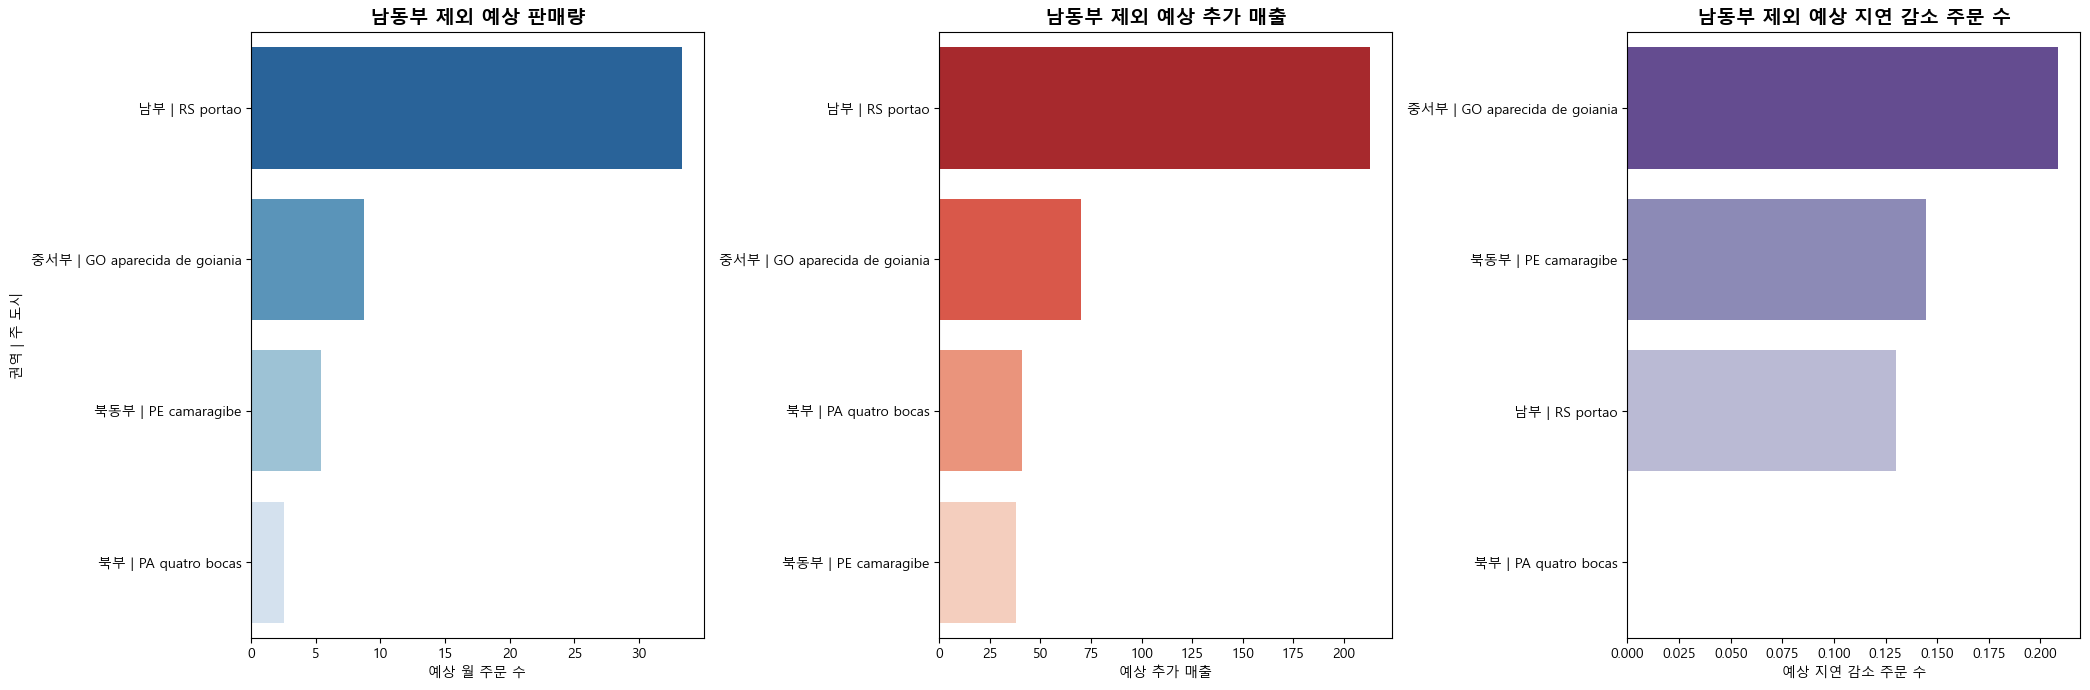

In [64]:
final_hub_plot_no_southeast = final_hub_by_region_viz[
    final_hub_by_region_viz["region"].ne("남동부")
].copy()

final_hub_plot_no_southeast["label"] = (
    final_hub_plot_no_southeast["region"].astype(str)
    + " | "
    + final_hub_plot_no_southeast["state"].astype(str)
    + " "
    + final_hub_plot_no_southeast["suggested_city"].astype(str)
)

display(final_hub_plot_no_southeast[[
    "region",
    "state",
    "suggested_city",
    "suggested_zip_code_prefix",
    "predicted_order_sum",
    "recommended_stock_sum",
    "expected_revenue_sum",
    "expected_additional_revenue",
    "expected_prevented_delay_orders",
    "covered_customer_orders",
    "covered_seller_orders",
    "avg_delivery_days",
    "late_rate",
    "avg_review_score",
    "avg_distance_to_hub_km"
]])

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

sns.barplot(
    data=final_hub_plot_no_southeast.sort_values("predicted_order_sum", ascending=False),
    y="label",
    x="predicted_order_sum",
    ax=axes[0],
    palette="Blues_r"
)
axes[0].set_title("남동부 제외 예상 판매량", fontsize=14, weight="bold")
axes[0].set_xlabel("예상 월 주문 수")
axes[0].set_ylabel("권역 | 주 도시")

sns.barplot(
    data=final_hub_plot_no_southeast.sort_values("expected_additional_revenue", ascending=False),
    y="label",
    x="expected_additional_revenue",
    ax=axes[1],
    palette="Reds_r"
)
axes[1].set_title("남동부 제외 예상 추가 매출", fontsize=14, weight="bold")
axes[1].set_xlabel("예상 추가 매출")
axes[1].set_ylabel("")

sns.barplot(
    data=final_hub_plot_no_southeast.sort_values("expected_prevented_delay_orders", ascending=False),
    y="label",
    x="expected_prevented_delay_orders",
    ax=axes[2],
    palette="Purples_r"
)
axes[2].set_title("남동부 제외 예상 지연 감소 주문 수", fontsize=14, weight="bold")
axes[2].set_xlabel("예상 지연 감소 주문 수")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

## 9. 최종 집하장별 우선 적재 카테고리

최종 선정된 집하장에 어떤 카테고리를 우선 적재해야 하는지 확인한다.

In [61]:
display(top_category_by_selected_state_viz[[
    "region",
    "customer_state",
    "suggested_city",
    "category",
    "predicted_monthly_order",
    "recommended_stock",
    "expected_revenue",
    "delay_rate",
    "avg_delivery_days",
    "avg_review_score"
]])

,region,customer_state,suggested_city,category,predicted_monthly_order,recommended_stock,expected_revenue,delay_rate,avg_delivery_days,avg_review_score
0,중서부,GO,aparecida de goiania,bed_bath_table,3.6782,7.0000,651.8935,0.0000,9.7500,3.5000
1,중서부,GO,aparecida de goiania,telephony,1.4033,2.0000,630.7419,0.0000,10.0000,4.0000
2,중서부,GO,aparecida de goiania,housewares,1.3744,3.0000,"1,465.2671",0.0000,10.0000,5.0000
3,중서부,GO,aparecida de goiania,sports_leisure,1.2142,3.0000,165.6005,0.6000,7.4000,5.0000
4,중서부,GO,aparecida de goiania,health_beauty,1.0272,3.0000,183.4126,0.0000,13.0000,5.0000
5,북부,PA,quatro bocas,auto,1.3255,3.0000,341.2020,0.0000,15.0000,4.0000
6,북부,PA,quatro bocas,furniture_decor,1.2283,2.0000,"1,647.4432",0.0000,8.0000,2.0000
7,북동부,PE,camaragibe,watches_gifts,2.4482,4.0000,421.1539,0.4000,14.2000,2.8000
8,북동부,PE,camaragibe,furniture_decor,1.7569,4.0000,765.8842,0.0000,12.0000,2.0000
9,북동부,PE,camaragibe,garden_tools,1.2081,2.0000,526.6276,0.0000,12.0000,2.0000


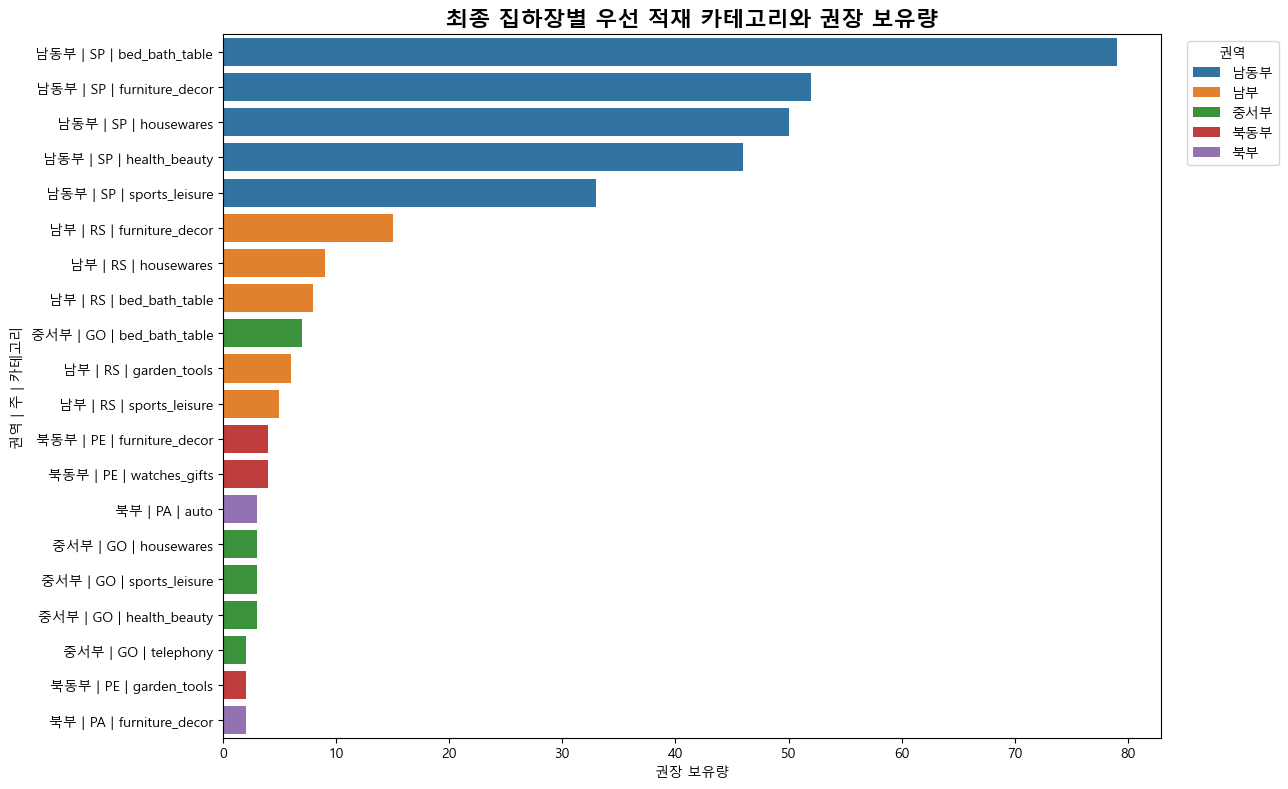

In [62]:
stock_plan_plot = top_category_by_selected_state_viz.copy()

stock_plan_plot["label"] = (
    stock_plan_plot["region"].astype(str)
    + " | "
    + stock_plan_plot["customer_state"].astype(str)
    + " | "
    + stock_plan_plot["category"].astype(str)
)

plt.figure(figsize=(13, 8))

sns.barplot(
    data=stock_plan_plot.sort_values("recommended_stock", ascending=False),
    y="label",
    x="recommended_stock",
    hue="region",
    dodge=False
)

plt.title("최종 집하장별 우선 적재 카테고리와 권장 보유량", fontsize=16, weight="bold")
plt.xlabel("권장 보유량")
plt.ylabel("권역 | 주 | 카테고리")
plt.legend(title="권역", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 10. 기대효과 종합 해석

본 분석은 사전재고와 집하장 운영의 기대효과를 예상 판매량, 권장 보유량, 예상 매출, 추가 주문 수, 추가 매출, 배송 지연 감소 주문 수, 리뷰점수 개선 관점에서 종합적으로 확인하였다.

예상 판매량은 해당 지역에서 실제로 처리할 수 있는 물량 규모를 의미한다. 예상 판매량이 높은 지역은 사전재고를 배치했을 때 운영 효율성이 높을 가능성이 있다.

권장 보유량은 예상 판매량과 과거 수요 변동성을 함께 반영한 값이다. 권장 보유량이 높은 지역과 카테고리는 집하장에 우선 적재할 필요성이 큰 품목으로 해석할 수 있다.

예상 추가 매출은 사전재고 운영으로 주문 증가가 발생한다고 가정했을 때의 사업적 기대효과이다. 추가 매출이 큰 지역은 투자 대비 성과를 기대할 수 있는 우선 후보로 볼 수 있다.

예상 지연 감소 주문 수는 배송 경험 개선 효과를 보여준다. 지연 감소 효과가 큰 지역은 고객 불만족 완화와 리뷰점수 개선 가능성이 높은 지역이다.

리뷰점수 개선 효과는 배송 지연 감소가 고객 만족도 향상으로 이어진다는 가정에 기반한 시뮬레이션이다. 따라서 실제 운영 결과를 확정하는 값이 아니라, 고객 경험 개선 가능성을 보여주는 보조 지표로 해석해야 한다.

최종적으로 예상 판매량, 추가 매출, 지연 감소 효과가 동시에 큰 지역은 사전재고 및 집하장 운영의 우선 후보로 볼 수 있다. 다만 실제 도입 전에는 창고 운영비, 보관비, 운송비 절감 효과, 재고 폐기 위험 등을 추가로 고려해야 한다.

## 지역별 기대효과 증가율 분석

기대효과는 절대값뿐 아니라 기존 대비 증가율로도 확인할 필요가 있다.

절대값은 규모가 큰 지역에 유리하고, 증가율은 상대적으로 개선 여지가 큰 지역을 보여준다.

본 분석에서는 기준 시나리오를 기준으로 다음 증가율을 계산한다.

1. 주문 증가율
2. 매출 증가율
3. 지연 주문 감소율
4. 리뷰점수 개선율

In [65]:
region_effect_pct = baseline_effect_detail.copy()

region_effect_pct["order_growth_pct"] = (
    region_effect_pct["expected_additional_orders"]
    / region_effect_pct["predicted_order_sum"]
    * 100
)

region_effect_pct["revenue_growth_pct"] = (
    region_effect_pct["expected_additional_revenue"]
    / region_effect_pct["expected_revenue_sum"]
    * 100
)

region_effect_pct["delay_reduction_pct"] = (
    region_effect_pct["expected_prevented_delay_orders"]
    / (
        region_effect_pct["predicted_order_sum"]
        * region_effect_pct["avg_delay_rate"]
    )
    * 100
)

region_effect_pct["review_uplift_pct"] = (
    (
        region_effect_pct["expected_review_score_after_effect"]
        - region_effect_pct["avg_review_score"]
    )
    / region_effect_pct["avg_review_score"]
    * 100
)

pct_cols = [
    "order_growth_pct",
    "revenue_growth_pct",
    "delay_reduction_pct",
    "review_uplift_pct"
]

for col in pct_cols:
    region_effect_pct[col] = region_effect_pct[col].replace([np.inf, -np.inf], np.nan)
    region_effect_pct[col] = region_effect_pct[col].fillna(0)

display(region_effect_pct[[
    "customer_region",
    "customer_state",
    "predicted_order_sum",
    "expected_revenue_sum",
    "avg_delay_rate",
    "avg_review_score",
    "expected_review_score_after_effect",
    "order_growth_pct",
    "revenue_growth_pct",
    "delay_reduction_pct",
    "review_uplift_pct"
]].sort_values("revenue_growth_pct", ascending=False).head(30))

,customer_region,customer_state,predicted_order_sum,expected_revenue_sum,avg_delay_rate,avg_review_score,expected_review_score_after_effect,order_growth_pct,revenue_growth_pct,delay_reduction_pct,review_uplift_pct
29,중서부,GO,8.6974,"3,096.9157",0.1200,4.5000,4.5600,2.0000,2.2554,20.0000,1.3333
31,중서부,MT,3.0075,558.4991,0.0000,5.0000,5.0000,2.0000,2.2240,0.0000,0.0000
17,남동부,MG,41.9139,"12,521.6702",0.0385,3.7903,3.8503,2.0000,2.2148,20.0000,1.5830
26,북동부,PE,5.4132,"1,713.6656",0.1333,2.2667,2.3267,2.0000,2.1983,20.0000,2.6471
21,남부,RS,33.3283,"9,940.8556",0.0195,4.2131,4.2731,2.0000,2.1426,20.0000,1.4241
18,남동부,RJ,55.4635,"11,115.8401",0.0236,3.1768,3.2368,2.0000,2.1208,20.0000,1.8887
23,북동부,BA,8.2205,"1,213.3443",0.0000,3.9583,4.0183,2.0000,2.0660,0.0000,1.5158
16,남동부,ES,3.8914,"1,563.8602",0.0000,3.3750,3.4350,2.0000,2.0633,0.0000,1.7778
27,북부,PA,2.5537,"1,988.6452",0.0000,3.0000,3.0600,2.0000,2.0530,0.0000,2.0000
19,남동부,SP,236.1997,"52,557.6879",0.1346,3.8231,3.8831,2.0000,2.0406,20.0000,1.5694


## 지역별 기대효과 증가율 시각화

아래 그래프는 기준 시나리오에서 지역별 기대효과가 기존 대비 몇 % 개선되는지 보여준다.

절대 규모가 큰 지역과 별개로, 상대적 개선 효과가 큰 지역을 확인할 수 있다.

In [66]:
region_pct_summary = (
    region_effect_pct
    .groupby("customer_region", as_index=False)
    .agg(
        order_growth_pct=("order_growth_pct", "mean"),
        revenue_growth_pct=("revenue_growth_pct", "mean"),
        delay_reduction_pct=("delay_reduction_pct", "mean"),
        review_uplift_pct=("review_uplift_pct", "mean")
    )
)

display(region_pct_summary)

,customer_region,order_growth_pct,revenue_growth_pct,delay_reduction_pct,review_uplift_pct
0,남동부,2.0000,2.1099,15.0000,1.7047
1,남부,2.0000,1.9559,20.0000,1.4564
2,북동부,2.0000,2.0750,5.0000,2.9157
3,북부,2.0000,2.0530,0.0000,2.0000
4,중서부,2.0000,2.1156,10.0000,2.3000


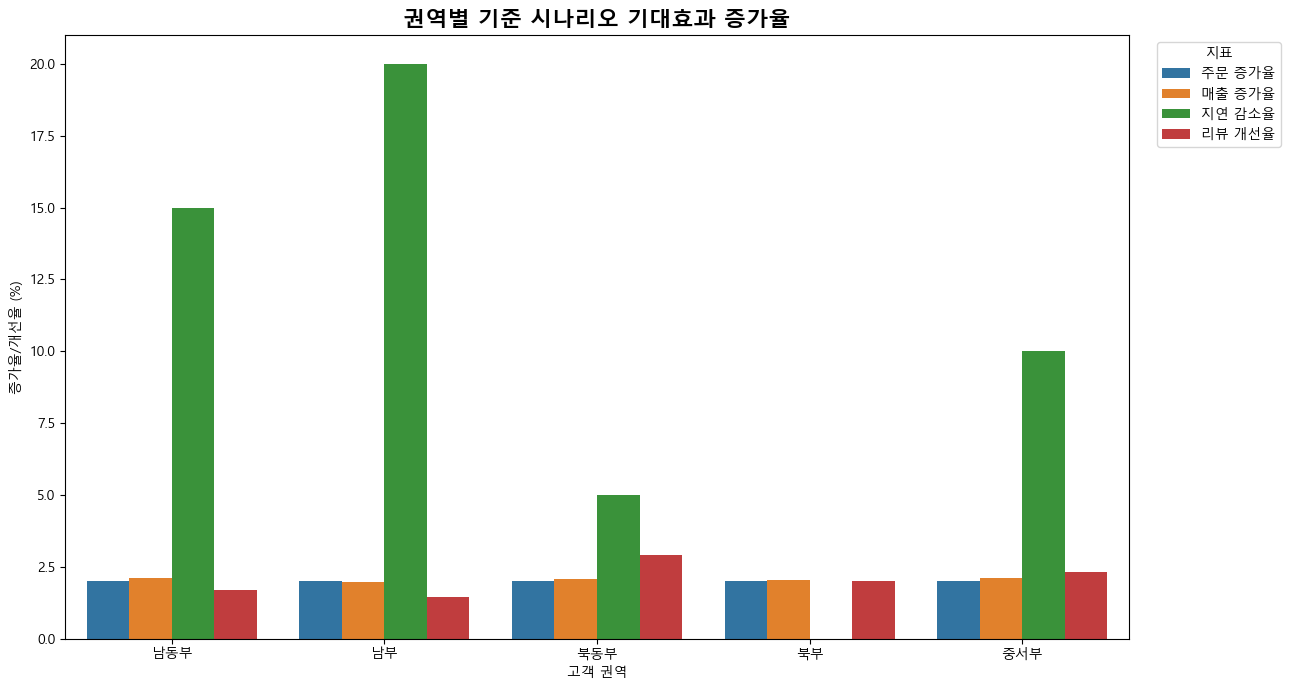

In [67]:
region_pct_long = region_pct_summary.melt(
    id_vars="customer_region",
    value_vars=[
        "order_growth_pct",
        "revenue_growth_pct",
        "delay_reduction_pct",
        "review_uplift_pct"
    ],
    var_name="metric",
    value_name="pct"
)

metric_name_map = {
    "order_growth_pct": "주문 증가율",
    "revenue_growth_pct": "매출 증가율",
    "delay_reduction_pct": "지연 감소율",
    "review_uplift_pct": "리뷰 개선율"
}

region_pct_long["metric"] = region_pct_long["metric"].map(metric_name_map)

plt.figure(figsize=(13, 7))

sns.barplot(
    data=region_pct_long,
    x="customer_region",
    y="pct",
    hue="metric"
)

plt.title("권역별 기준 시나리오 기대효과 증가율", fontsize=16, weight="bold")
plt.xlabel("고객 권역")
plt.ylabel("증가율/개선율 (%)")
plt.legend(title="지표", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 주별 기대효과 증가율 Top 지역

권역 평균이 아니라 주 단위로 기대효과 증가율이 높은 지역을 확인한다.

C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\356071210.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\356071210.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yiho1\AppData\Local\Temp\ipykernel_46500\356071210.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


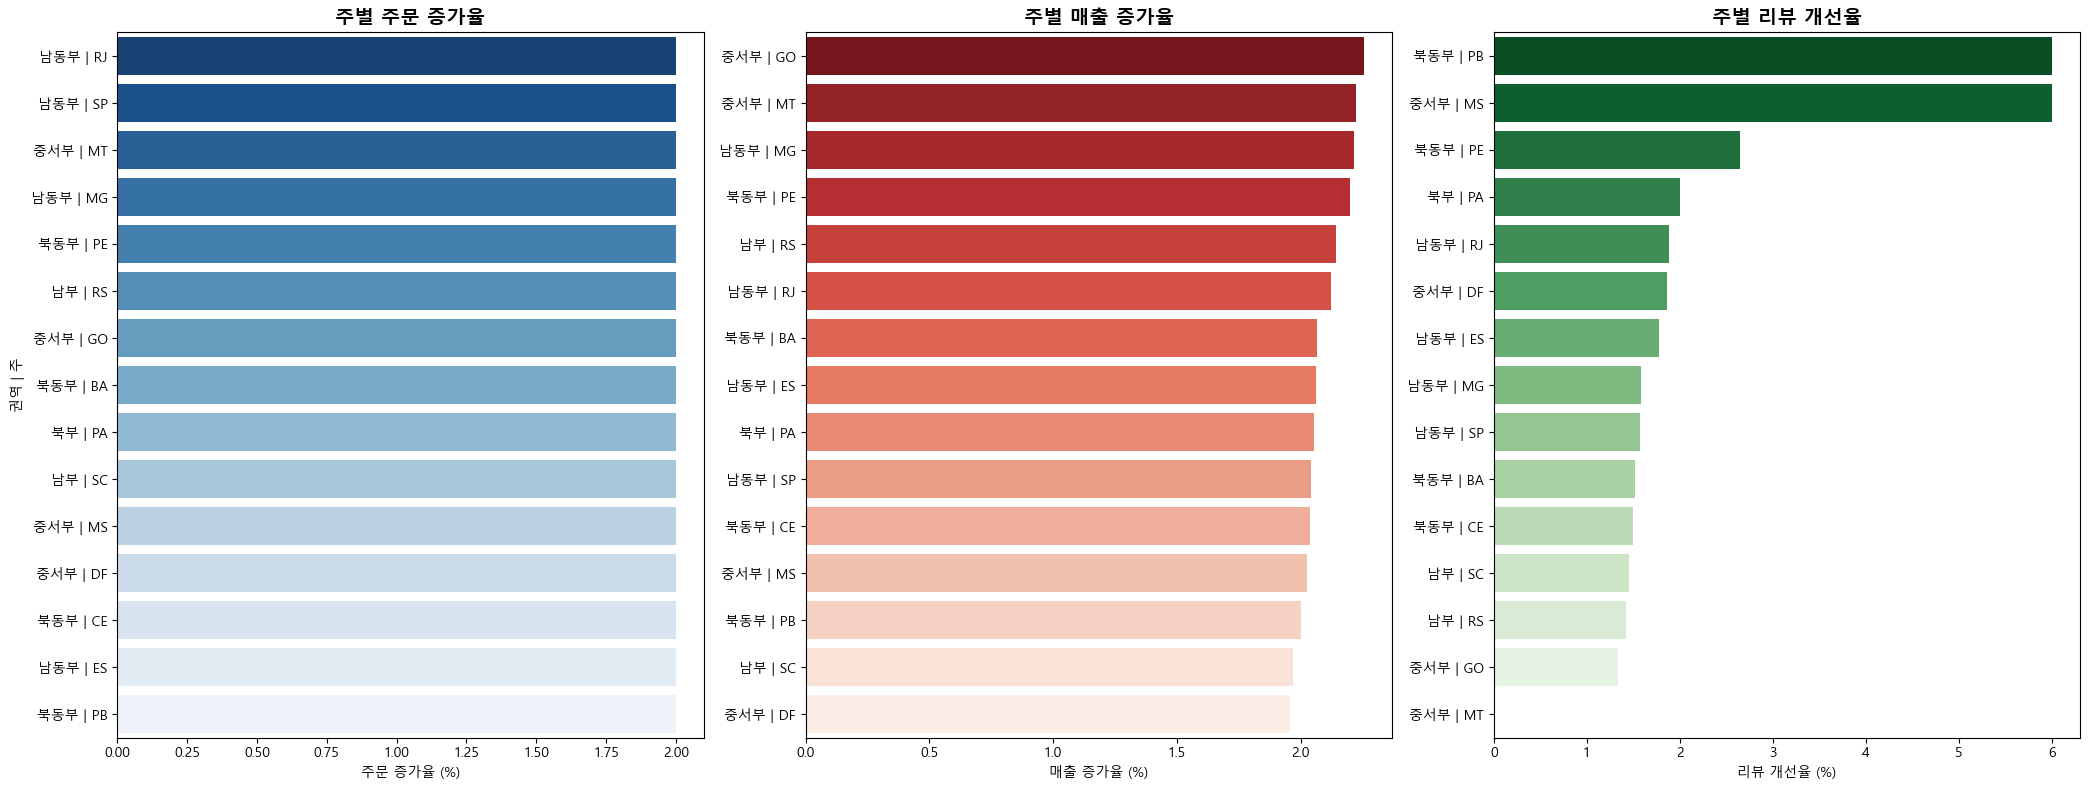

In [68]:
state_pct_plot = region_effect_pct.copy()

state_pct_plot["label"] = (
    state_pct_plot["customer_region"].astype(str)
    + " | "
    + state_pct_plot["customer_state"].astype(str)
)

top_state_pct = state_pct_plot.sort_values(
    "revenue_growth_pct",
    ascending=False
).head(15)

fig, axes = plt.subplots(1, 3, figsize=(21, 8))

sns.barplot(
    data=top_state_pct.sort_values("order_growth_pct", ascending=False),
    y="label",
    x="order_growth_pct",
    ax=axes[0],
    palette="Blues_r"
)
axes[0].set_title("주별 주문 증가율", fontsize=14, weight="bold")
axes[0].set_xlabel("주문 증가율 (%)")
axes[0].set_ylabel("권역 | 주")

sns.barplot(
    data=top_state_pct.sort_values("revenue_growth_pct", ascending=False),
    y="label",
    x="revenue_growth_pct",
    ax=axes[1],
    palette="Reds_r"
)
axes[1].set_title("주별 매출 증가율", fontsize=14, weight="bold")
axes[1].set_xlabel("매출 증가율 (%)")
axes[1].set_ylabel("")

sns.barplot(
    data=top_state_pct.sort_values("review_uplift_pct", ascending=False),
    y="label",
    x="review_uplift_pct",
    ax=axes[2],
    palette="Greens_r"
)
axes[2].set_title("주별 리뷰 개선율", fontsize=14, weight="bold")
axes[2].set_xlabel("리뷰 개선율 (%)")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()